# Grande volume de dados

Este é um material de consulta sobre o terceiro tópico de estudos. Sinta-se a vontade para voltar aqui sempre que necessário.

## Índice :
* [Medidas de Tendência Central e Variabilidade I](#first-bullet)
* [Bibliotecas](#second-bullet)
* [Pandas](#third-bullet)
* [Tipos de Variáveis](#fourth-bullet)

## Medidas de Tendência Central e Variabilidade I <a class="anchor" id="first-bullet"></a>

A advocacia no setor contencioso exige conhecimento qualificado do comportamento e tendências de sentença de diferentes tribunais e varas. A estratégia de litígio varia conforme as previsões sobre a mediação e conciliação, sobre o resultado de um processo judicial ou sobre o resultado de um recurso.
Vamos utilizar uma base de dados reais e anonimizados de uma plataforma de mediação online. 


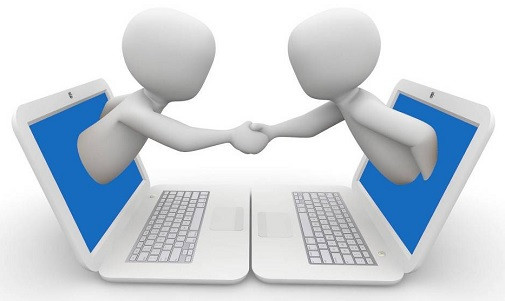
*Fonte: Migalhas.com.br*

Ela contém diversas informações sobre cada conflito mediado como, por exemplo, setor da empresa, comarca, vara, valor da proposta inicial feita ao consumidor, valor das propostas seguintes na tentativa de alcançar chegar a um meio termo e o resultado final, se houve ou não acordo.
Quando se trata de conhecer e compreender os padrões de conflitos e processos judiciais, a única ferramenta que advogad@s possuem é a estatística. Uma parte dessa análise de padrões processuais para tomada de decisão com base em evidências envolve o uso de medidas de tendência central e de variabilidade. 

Existem duas maneiras de conhecer e avaliar essas medidas: seus valores e suas representações gráficas. O código abaixo abre uma base de dados, um arquivo na mesma pasta de nosso arquivo main.py, contendo ***40.506 casos de conflitos consumeristas*** - desentedimento entre o fornecedor e o consumidor, chamado 'mediacao.csv'. 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (20, 10)
font = {'weight':'bold','size': 22}
matplotlib.rc('font', **font)


mediacao = pd.read_csv('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/mediacao.csv')
mediacao.Proposta1 = mediacao.Proposta1.str.replace('R$','',regex=False).str.replace(',','',regex=False)
mediacao.Proposta1 = mediacao.Proposta1.astype('float')
mediacao.Ultima_proposta = mediacao.Ultima_proposta.str.replace('R$','',regex=False).str.replace(',','',regex=False)
mediacao.Ultima_proposta = mediacao.Ultima_proposta.astype('float')
print(mediacao.head(20))


             Empresa  Autor Estado               Comarca  \
0          Telecom 3   3971     RJ     FORUM NOVA IGUACU   
1          Telecom 4  16934     MG   Belo Horizonte - MG   
2          Telecom 4  19302     RJ  Duque de Caxias - RJ   
3          Telecom 2  20208     BA                   NaN   
4          Telecom 2  22082     RN                 Natal   
5          Telecom 2  18423     MG           Sete Lagoas   
6          Telecom 1  20572     MG   Belo Horizonte - MG   
7          Telecom 2  15985     BA              Guanambi   
8          Telecom 2  22348     MG               Formiga   
9          Telecom 2  10671     MG        Águas Formosas   
10         Telecom 2  12484     CE                Assaré   
11         Telecom 2   9337     CE               Quixelô   
12         Telecom 2   5910     CE                Assaré   
13         Telecom 2  22872     RN              Caraúbas   
14  Eletrodomésticos   9338     RJ        Rio de Janeiro   
15  Eletrodomésticos  16628     BA      

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:2882: DtypeWarning: Columns (6,17,18) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


Essas colunas com seus respectivos valores são salvas em duas variáveis.

Em seguida, geramos um gráfico do tipo histograma com os valores em reais da primeira e da última proposta feitas pelo fornecedor ao consumidor infatisfeito ou lesado.



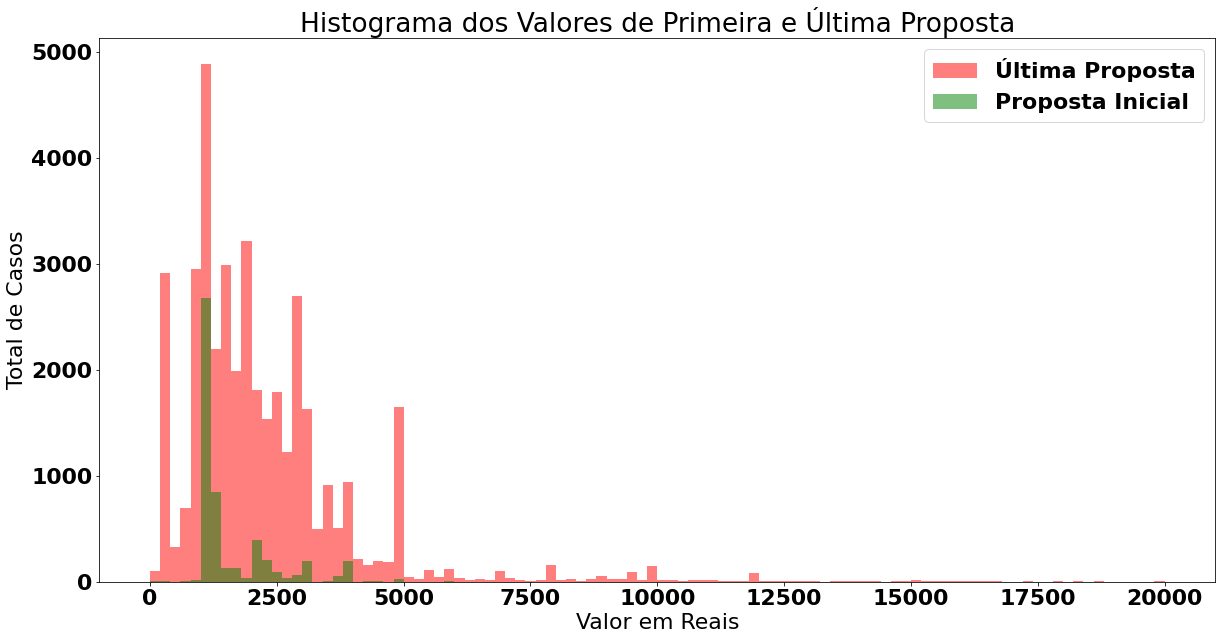

In [ ]:
ultima = mediacao.Ultima_proposta
primeira = mediacao.Proposta1
ultima = ultima[np.logical_not(np.isnan(ultima))]



#Geração do gráfico
plt.hist(ultima,range=(1,20000),label='Última Proposta',bins=100,alpha=0.5,color='red')
plt.hist(primeira,range=(1,20000),label='Proposta Inicial',bins=100,alpha=0.5,color='green')
plt.ylabel('Total de Casos')
plt.xlabel('Valor em Reais')
plt.title('Histograma dos Valores de Primeira e Última Proposta')
plt.legend()




O que o gráfico mostra? Quais informações juridicamente relevantes ele revela?

Um primeiro conjunto de informações estatísticas relevantes envolve medidas de tendência central: o que é mais comum nos valores em reais dessas causas? Existem conflitos com valores mais baixos ou valores altos, mas o que é o padrão? 

Imagine 5 causas com os seguintes valores:


In [ ]:
causas = [5000, 5000, 6000, 7000, 10000]



A medida mais conhecida de tendência central desses valores é a média. Ela pode ser calculada da seguinte maneira:

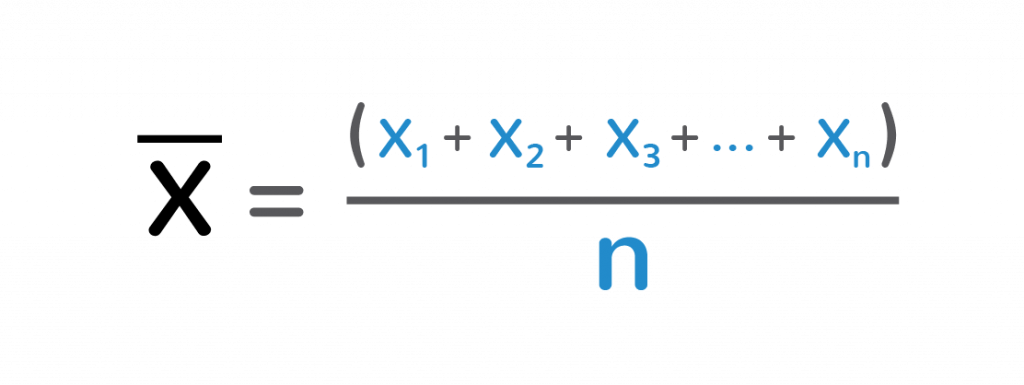

Outra maneira de expressar a mesma fórmula é:

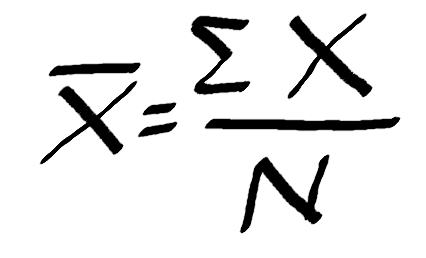

Isso pode ser executado no Python:

In [ ]:
media_causas = (5000+5000+6000+7000+10000)/len(causas)


Trata-se da soma dos valores dividida pelo número de causas. A biblioteca Numpy do Python oferece funções que permitem realizar esses cálculos com rapidez e simplicidade:


In [ ]:
media_causas == np.mean(causas)

True

In [ ]:
print(ultima)

0         1500.0
1         3700.0
2         1200.0
3         1000.0
4         1250.0
          ...   
40501     1000.0
40502     8000.0
40503     4500.0
40504    10000.0
40505     6000.0
Name: Ultima_proposta, Length: 39907, dtype: float64


In [ ]:
media_primeira_proposta = np.mean(primeira)
media_ultima_proposta = np.mean(ultima)

print(media_primeira_proposta)
print(media_ultima_proposta)

1599.5906976744186
2393.0137231563385


Vamos gerar novamente o mesmo gráfico, porém mostrando as médias da primeira e última proposta

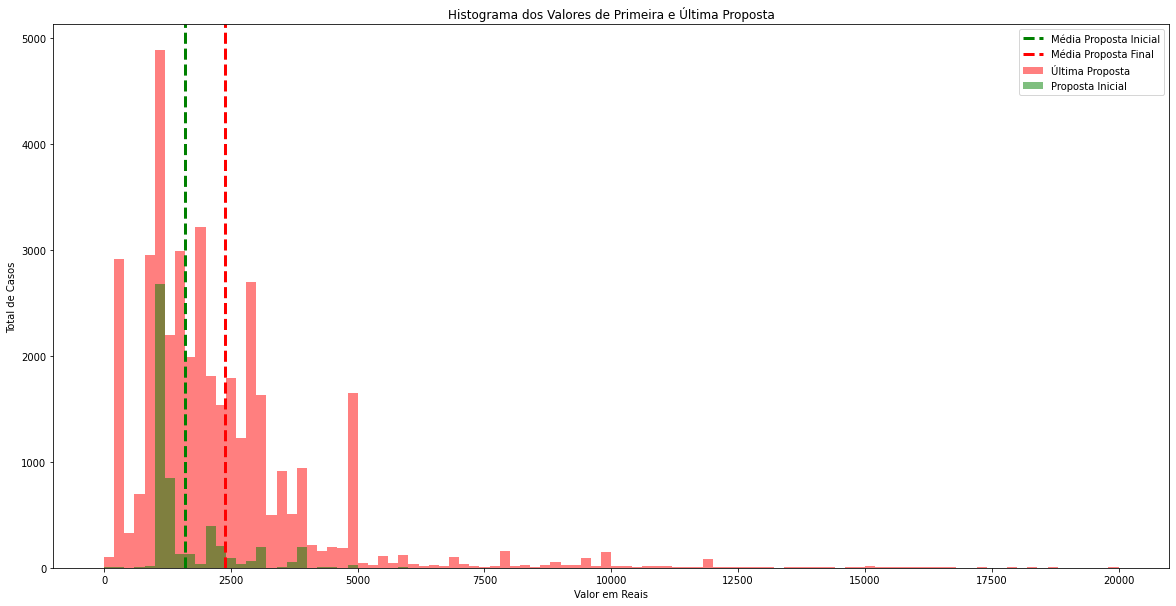

In [ ]:
plt.hist(ultima,range=(1,20000),label='Última Proposta',bins=100,alpha=0.5,color='red')
plt.hist(primeira,range=(1,20000),label='Proposta Inicial',bins=100,alpha=0.5,color='green')
plt.axvline(media_primeira_proposta,label='Média Proposta Inicial',color='green',linewidth=3,linestyle='--')
plt.axvline(media_ultima_proposta,label='Média Proposta Final',color='red',linewidth=3,linestyle='--')
plt.ylabel('Total de Casos')
plt.xlabel('Valor em Reais')
plt.title('Histograma dos Valores de Primeira e Última Proposta')
plt.legend()


Quais informações juridicamente relevantes são fornecidas pelo gráfico? Qual média é maior? Por qual razão?

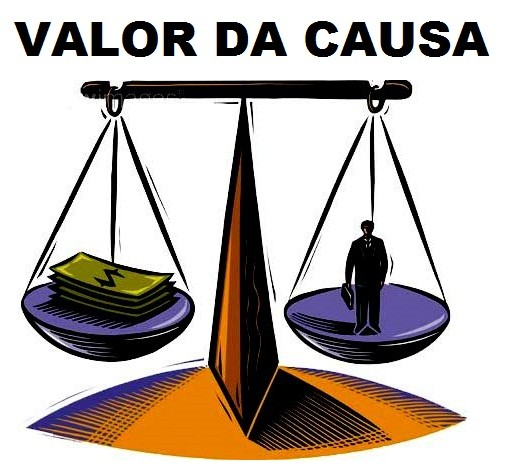

*Fonte: Blog Maxi Educa


Outra medida de tendência central é a mediana. Ela indica o valor que está no meio do caminho. Voltemos à nossa lista com apenas 5 causas:


In [ ]:
causas

[5000, 5000, 6000, 7000, 10000]

A mediana de 'causas' é 6000, pois é o valor que separa a metade menor das causas (5000 e 5000) da metade maior das causas (7000 e 10000).

Quando o número de valores na série for par, a mediana será a média entre os dois valores do meio do caminho:

In [ ]:
mais_causas = [5000, 5000, 6000, 8000, 9000, 10000]

mediana_mais_causas = (6000 + 8000)/2

A biblioteca Numpy também possui uma função para cálculo da mediana:

In [ ]:
mediana_mais_causas == np.median(mais_causas)

True

A diferença crucial entre a média e a mediana é que a mediana não é afetada por valores excepcionalmente altos ou baixos. Em nossa lista 'causas' a mediana será sempre a mesma, não importa o valor da causa mais cara.

In [ ]:
print(causas)

causas[-1] = 20000

print(causas)

[5000, 5000, 6000, 7000, 10000]
[5000, 5000, 6000, 7000, 20000]


In [ ]:
np.median(causas)

6000.0

In [ ]:
causas[-1] = 500000

np.median(causas)

6000.0

Vamos comparar a média e mediana no caso dos valores da última proposta de acordo nos casos de nossa base. Dado que já temos todos os valores de última proposta salvos em 'ultima', para obter a mediana de 'ultima' basta usar a mesma função do Numpy:


np.median(ultima)

Com isso, podemos montar nosso gráfico:

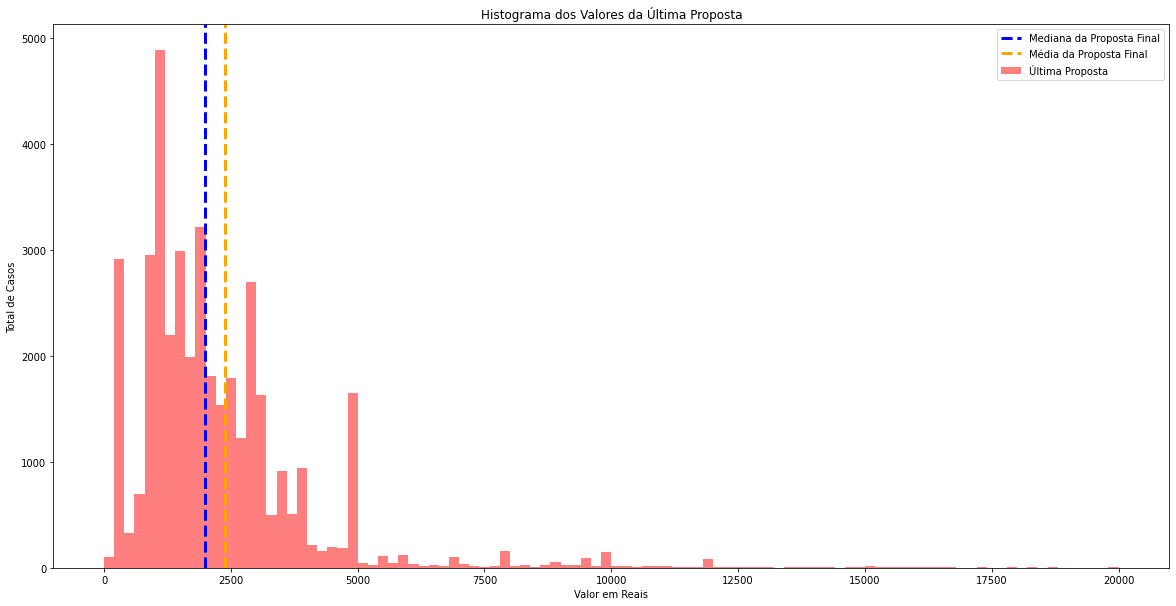

In [ ]:
mediana_ultima_proposta = np.median(ultima)

plt.hist(ultima,range=(1,20000),label='Última Proposta',bins=100,alpha=0.5,color='red')
plt.axvline(mediana_ultima_proposta,label='Mediana da Proposta Final',color='blue',linewidth=3,linestyle='--')
plt.axvline(media_ultima_proposta,label='Média da Proposta Final',color='orange',linewidth=3,linestyle='--')
plt.ylabel('Total de Casos')
plt.xlabel('Valor em Reais')
plt.title('Histograma dos Valores da Última Proposta')
plt.legend()

A mediana é igual à média, no caso dos valores de proposta final feita pelo fornecedor?

Por qual razão?

Uma terceira medida de tendência central é a moda. A moda representa o valor que ocorre com maior frequência na série de dados. 

In [ ]:
causas

[5000, 5000, 6000, 7000, 500000]

O valor que ocorre com maior frequência em 'causas' é R$ 5000. 

Importante: para um conjunto de valores, existirá apenas uma média e uma mediana. Porém podem existir múltiplas modas.

In [ ]:
causas_novas = [5000, 5000, 6000, 7000, 8500, 9000, 10500, 10500, 12000, 12500, 13000, 13000, 500000]

Em 'causas_novas' temos 3 modas: 5000, 10500 e 13000 reais. 

Todas essas medidas permitem saber o que é comum no todo dos valores de propostas de acordo. Também permitem comparar um conjunto de propostas - a primeira e a última, no decorrer da mediação - para fazer afirmações sobre qual costuma ser mais custosa para a empresa. Se o valor da última proposta costuma ser, em média, mais alto, então a empresa sabe que deveria fazer um esforço para concluir o acordo em uma primeira proposta.


Medidas de tendência central também permitem que o departamento jurídico da empresa faça avaliações informadas sobre o nível do risco - passivo judicial - em diferentes comarcas. 


Para conhecer a performance e o passivo judicial de três diferentes empresas de telecomunicações em três grandes comarcas, vamos primeiro organizar os valores da última proposta em um dicionário:

In [ ]:
valores_organizados = {}
telecom1 = mediacao[mediacao.Empresa == 'Telecom 1']
telecom2 = mediacao[mediacao.Empresa == 'Telecom 2']
telecom3 = mediacao[mediacao.Empresa == 'Telecom 3']

valores_organizados['Telecom1'] = {}
valores_organizados['Telecom2'] = {}
valores_organizados['Telecom3'] = {}

valores_organizados['Telecom1']['São Paulo'] = telecom1.Ultima_proposta[(telecom1.Comarca == 'São Paulo') | (telecom1.Comarca == 'SAO PAULO')]
valores_organizados['Telecom2']['São Paulo'] = telecom2.Ultima_proposta[(telecom2.Comarca == 'São Paulo') | (telecom2.Comarca == 'SAO PAULO')]
valores_organizados['Telecom3']['São Paulo'] = telecom3.Ultima_proposta[(telecom3.Comarca == 'São Paulo') | (telecom3.Comarca == 'SAO PAULO')]

valores_organizados['Telecom1']['Rio de Janeiro'] = telecom1.Ultima_proposta[(telecom1.Comarca == 'RIO DE JANEIRO') | (telecom1.Comarca == 'Rio de Janeiro')]
valores_organizados['Telecom2']['Rio de Janeiro'] = telecom2.Ultima_proposta[(telecom2.Comarca == 'RIO DE JANEIRO') | (telecom2.Comarca == 'Rio de Janeiro')]
valores_organizados['Telecom3']['Rio de Janeiro'] = telecom3.Ultima_proposta[(telecom3.Comarca == 'RIO DE JANEIRO') | (telecom3.Comarca == 'Rio de Janeiro')]

valores_organizados['Telecom1']['Belo Horizonte'] = telecom1.Ultima_proposta[(telecom1.Comarca == 'BELO HORIZONTE') | (telecom1.Comarca == 'Belo Horizonte')]
valores_organizados['Telecom2']['Belo Horizonte'] = telecom2.Ultima_proposta[(telecom2.Comarca == 'BELO HORIZONTE') | (telecom2.Comarca == 'Belo Horizonte')]
valores_organizados['Telecom3']['Belo Horizonte'] = telecom3.Ultima_proposta[(telecom3.Comarca == 'BELO HORIZONTE') | (telecom3.Comarca == 'Belo Horizonte')]


Agora podemos criar gráficos que informem rapidamente qual empresa está fechando acordos mais baratos em uma determinada comarca - o Rio de Janeiro, por exemplo:

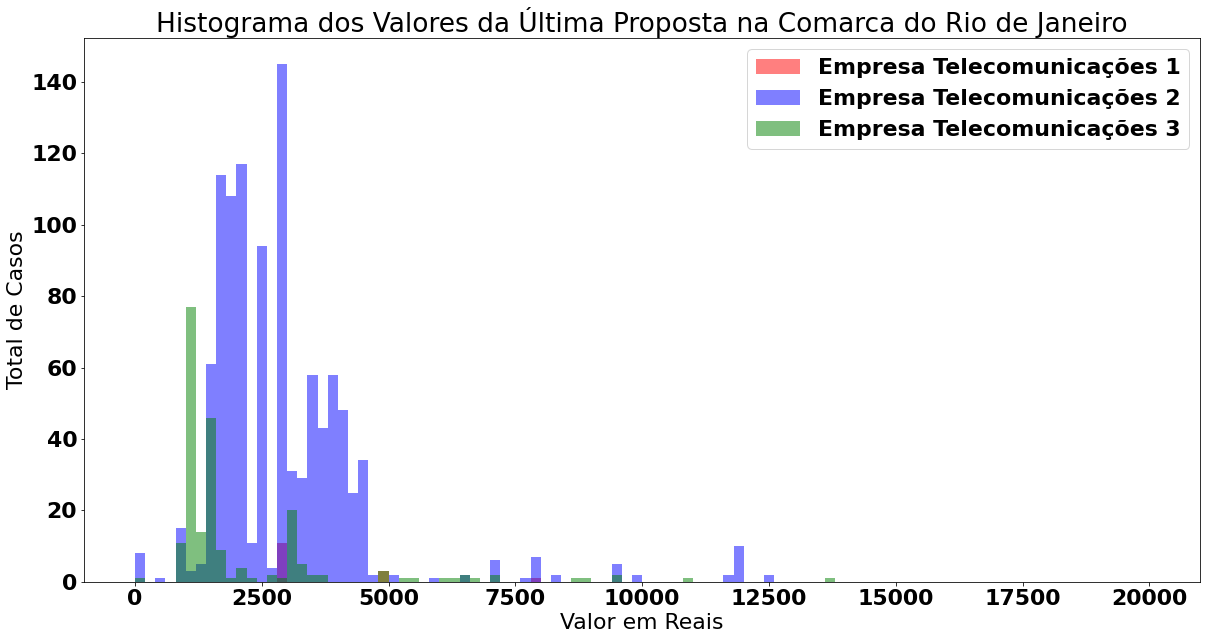

In [ ]:
plt.hist(valores_organizados['Telecom1']['Rio de Janeiro'],range=(1,20000),label='Empresa Telecomunicações 1',bins=100,alpha=0.5,color='red')
plt.hist(valores_organizados['Telecom2']['Rio de Janeiro'],range=(1,20000),label='Empresa Telecomunicações 2',bins=100,alpha=0.5,color='blue')
plt.hist(valores_organizados['Telecom3']['Rio de Janeiro'],range=(1,20000),label='Empresa Telecomunicações 3',bins=100,alpha=0.5,color='green')
plt.ylabel('Total de Casos')
plt.xlabel('Valor em Reais')
plt.title('Histograma dos Valores da Última Proposta na Comarca do Rio de Janeiro')
plt.legend()

Com base na distribuição dos valores da última proposta é possível determinar que a empresa 3 está conseguindo acordos mais baratos do que a empresa 2.

Como podemos ter certeza?

In [ ]:
telecom2_media_Rio = np.mean(valores_organizados['Telecom2']['Rio de Janeiro'])
telecom3_media_Rio = np.mean(valores_organizados['Telecom3']['Rio de Janeiro'])

print(telecom2_media_Rio)
print(telecom3_media_Rio)

2943.971590909091
2099.9205607476633


Vamos colocar essas médias no gráfico para poder compará-las:

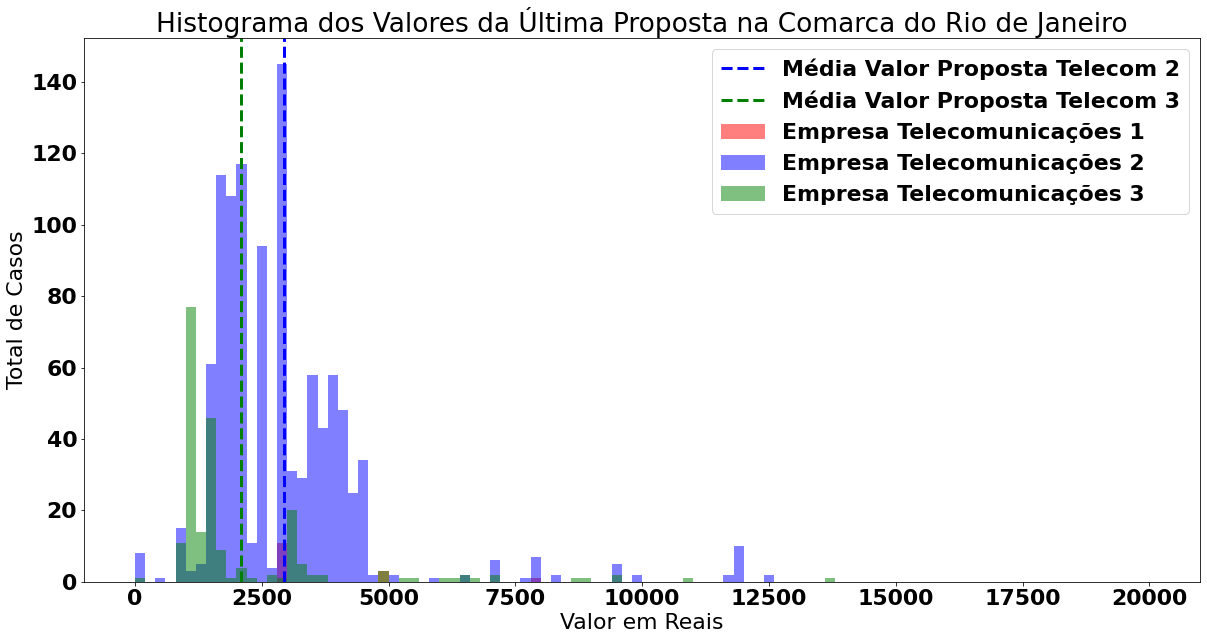

In [ ]:
plt.hist(valores_organizados['Telecom1']['Rio de Janeiro'],range=(1,20000),label='Empresa Telecomunicações 1',bins=100,alpha=0.5,color='red')
plt.hist(valores_organizados['Telecom2']['Rio de Janeiro'],range=(1,20000),label='Empresa Telecomunicações 2',bins=100,alpha=0.5,color='blue')
plt.hist(valores_organizados['Telecom3']['Rio de Janeiro'],range=(1,20000),label='Empresa Telecomunicações 3',bins=100,alpha=0.5,color='green')
plt.axvline(telecom2_media_Rio,label='Média Valor Proposta Telecom 2',color='blue',linewidth=3,linestyle='--')
plt.axvline(telecom3_media_Rio,label='Média Valor Proposta Telecom 3',color='green',linewidth=3,linestyle='--')
plt.ylabel('Total de Casos')
plt.xlabel('Valor em Reais')
plt.title('Histograma dos Valores da Última Proposta na Comarca do Rio de Janeiro')
plt.legend()

Também podemos comparar o risco para uma mesma empresa em diferentes comarcas:

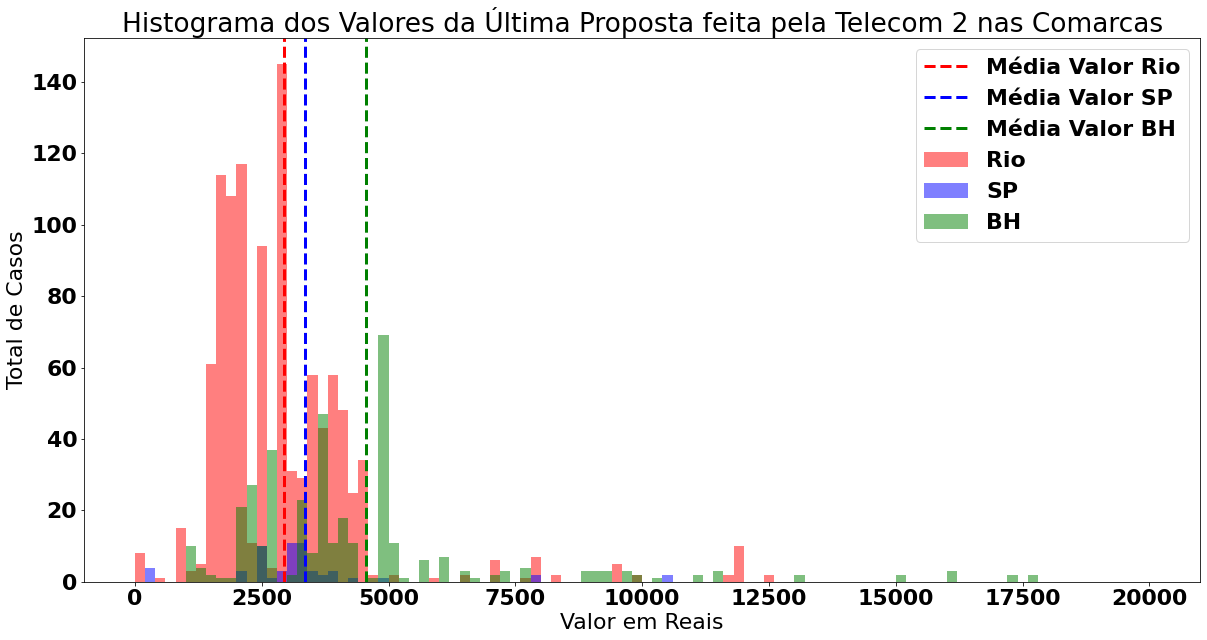

In [ ]:
plt.hist(valores_organizados['Telecom2']['Rio de Janeiro'],range=(1,20000),label='Rio',bins=100,alpha=0.5,color='red')
plt.hist(valores_organizados['Telecom2']['São Paulo'],range=(1,20000),label='SP',bins=100,alpha=0.5,color='blue')
plt.hist(valores_organizados['Telecom2']['Belo Horizonte'],range=(1,20000),label='BH',bins=100,alpha=0.5,color='green')
plt.axvline(np.mean(valores_organizados['Telecom2']['Rio de Janeiro']),label='Média Valor Rio',color='red',linewidth=3,linestyle='--')
plt.axvline(np.mean(valores_organizados['Telecom2']['São Paulo']),label='Média Valor SP',color='blue',linewidth=3,linestyle='--')
plt.axvline(np.mean(valores_organizados['Telecom2']['Belo Horizonte']),label='Média Valor BH',color='green',linewidth=3,linestyle='--')
plt.ylabel('Total de Casos')
plt.xlabel('Valor em Reais')
plt.title('Histograma dos Valores da Última Proposta feita pela Telecom 2 nas Comarcas')
plt.legend()

As médias em cada comarca podem ser calculadas seguindo a mesma função já vista:

In [ ]:
media_telecom2_Rio = np.mean(valores_organizados['Telecom2']['Rio de Janeiro'])
media_telecom2_SP = np.mean(valores_organizados['Telecom2']['São Paulo'])
media_telecom2_BH = np.mean(valores_organizados['Telecom2']['Belo Horizonte'])
        

Saber a tendência central, no entanto, não permite tomar decisões sobre o nível de variação dos valores de acordo. Imagine os valores de acordos feitos no ano passado por uma empresa em duas comarcas:

In [ ]:
acordos_rio = [4500, 4700, 5200, 5400, 5500]
acordos_sp = [500, 700, 2000, 3000, 3900, 9000, 10500, 11000]

media_rio = np.mean(acordos_rio)
media_sp = np.mean(acordos_sp)
print(media_rio)
print(media_sp)

5060.0
5075.0


Em qual comarca a empresa possui maior risco com seu passivo judicial? Muito embora em ambas a média do valor de acordo seja igual, em São Paulo o valor dos acordos **varia** muito mais, causando menor **previsibilidade**. A empresa pode fechar o acordo em apenas 500 reais, mas talvez seja obrigada a desembolsar 11.000 reais. Para o departamento jurídico da empresa ou o escritório de advocacia que a representa, a comarca de São Paulo é difícil de prever. Comparado com o Rio de Janeiro, em São Paulo o risco gerado por insatisfações do consumidor que criem chances de um conflito é maior.

A razão para isso é que a variabilidade no valor dos acordos no Rio de Janeiro é menor do que a variabilidade dos acordos em São Paulo. Isso pode ser medido pelo desvio padrão. O desvio padrão conta a distância entre cada valor de acordo e a média. 

In [ ]:
primeira_distancia = 4500 - media_rio
segunda_distancia = 4700 - media_rio
terceira_distancia = 5200 - media_rio
quarta_distancia = 5400 - media_rio
quinta_distancia = 5500 - media_rio



O desvio padrão é calculado segundo a seguinte fórmula:

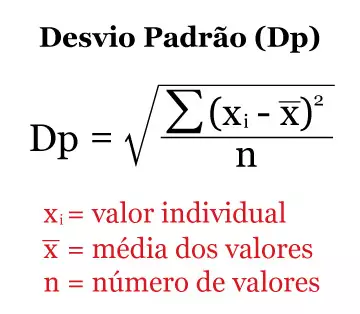
*Fonte: Educa Mais Brasil*

In [ ]:
soma = (primeira_distancia **2 + segunda_distancia**2 + terceira_distancia**2 + quarta_distancia**2 + quinta_distancia**2)
variancia = soma/len(acordos_rio)
desvio_padrao = variancia**0.5

print(desvio_padrao)

A biblioteca Numpy também possui uma função para calcular o desvio padrão de um conjunto de valores:

In [ ]:
desvio_padrao == np.std(acordos_rio)

True

O desvio padrão, assim como a média, tem por unidade a mesma dos valores de acordo: reais. 

Com essa medida de variabilidade, podemos avaliar em qual comarca a empresa de telecomunicações 2 de nossa base de acordos extrajudiciais enfrenta maior imprevisibilidade:

In [ ]:
desviopadrao_telecom2_Rio = np.std(valores_organizados['Telecom2']['Rio de Janeiro'])
desviopadrao_telecom2_SP = np.std(valores_organizados['Telecom2']['São Paulo'])
desviopadrao_telecom2_BH = np.std(valores_organizados['Telecom2']['Belo Horizonte'])
        
print('No Rio de Janeiro a variabilidade dos acordos feitos pela empresa é de',round(desviopadrao_telecom2_Rio,2),'reais.')
print('Em São Paulo a variabilidade dos acordos feitos pela empresa é de',round(desviopadrao_telecom2_SP,2),'reais.')
print('Em Belo Horizonte a variabilidade dos acordos feitos pela empresa é de',round(desviopadrao_telecom2_BH,2),'reais.')


No Rio de Janeiro a variabilidade dos acordos feitos pela empresa é de 1650.84 reais.
Em São Paulo a variabilidade dos acordos feitos pela empresa é de 1879.71 reais.
Em Belo Horizonte a variabilidade dos acordos feitos pela empresa é de 3143.34 reais.


Podemos representar o desvio padrão no mesmo gráfico:

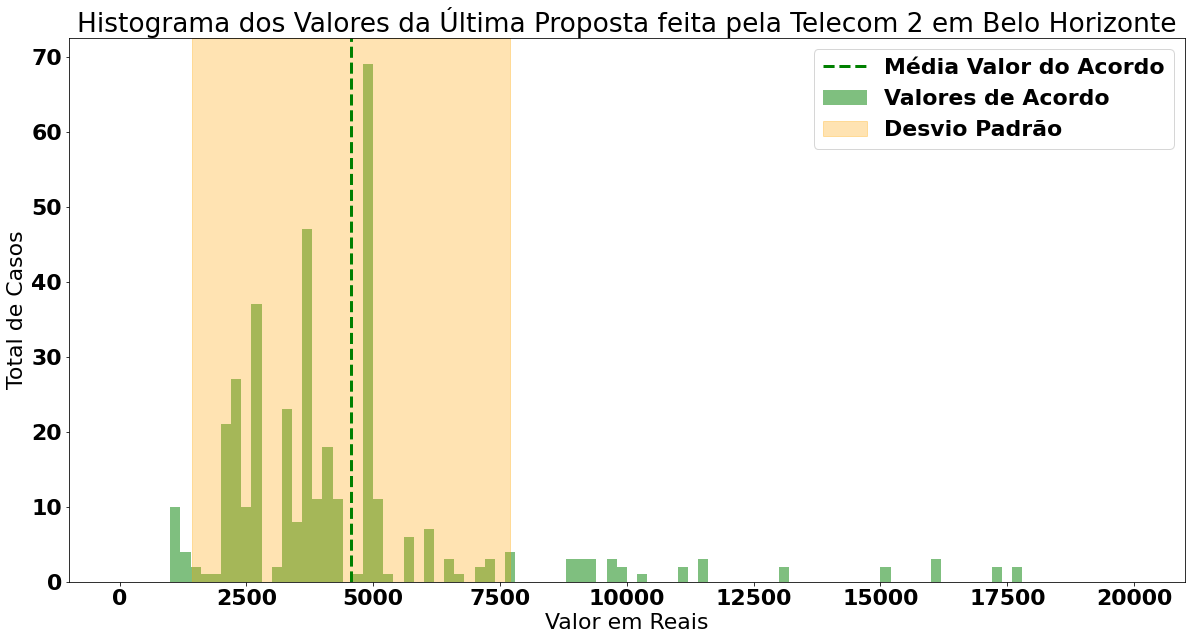

In [ ]:
plt.hist(valores_organizados['Telecom2']['Belo Horizonte'],range=(1,20000),label='Valores de Acordo',bins=100,alpha=0.5,color='green')
plt.axvline(np.mean(valores_organizados['Telecom2']['Belo Horizonte']),label='Média Valor do Acordo',color='green',linewidth=3,linestyle='--')
plt.axvspan(media_telecom2_BH - desviopadrao_telecom2_BH, media_telecom2_BH + desviopadrao_telecom2_BH,alpha=0.3,color='orange',label='Desvio Padrão')
plt.ylabel('Total de Casos')
plt.xlabel('Valor em Reais')
plt.title('Histograma dos Valores da Última Proposta feita pela Telecom 2 em Belo Horizonte')
plt.legend()

Compare o campo de possibilidades dos acordos em Belo Horizonte, acima, com o mesmo campo de possibilidades no Rio de Janeiro, abaixo. Qual comarca é mais arriscada para essa empresa?

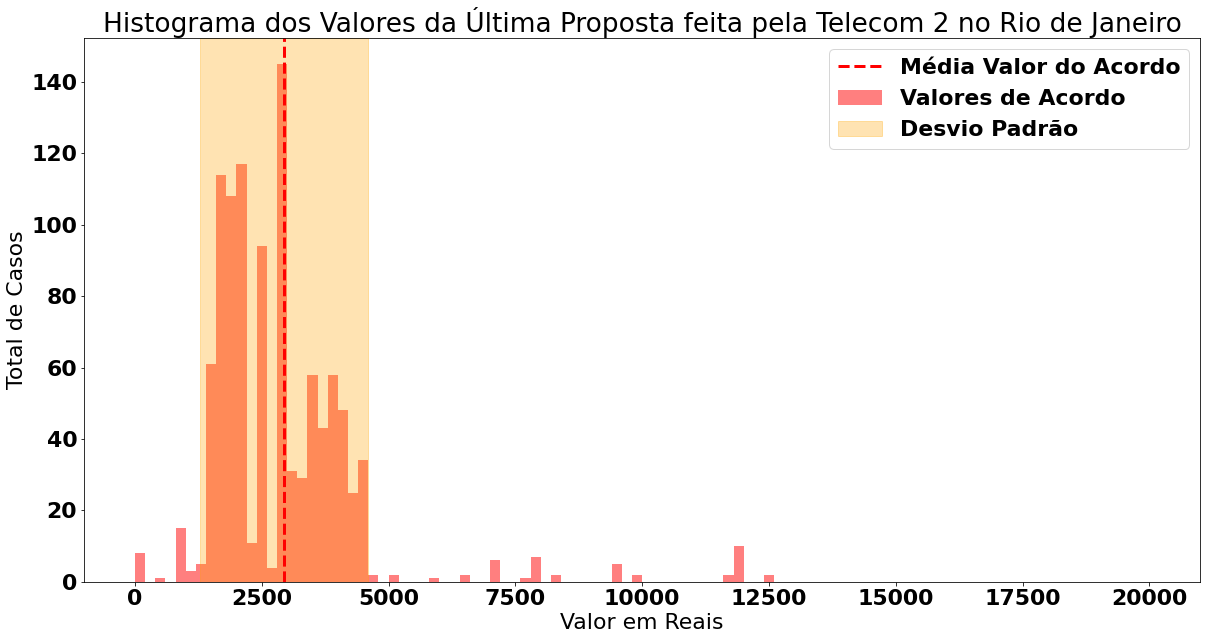

In [ ]:
plt.hist(valores_organizados['Telecom2']['Rio de Janeiro'],range=(1,20000),label='Valores de Acordo',bins=100,alpha=0.5,color='red')
plt.axvline(np.mean(valores_organizados['Telecom2']['Rio de Janeiro']),label='Média Valor do Acordo',color='red',linewidth=3,linestyle='--')
plt.axvspan(media_telecom2_Rio - desviopadrao_telecom2_Rio, media_telecom2_Rio + desviopadrao_telecom2_Rio,alpha=0.3,color='orange',label='Desvio Padrão')
plt.ylabel('Total de Casos')
plt.xlabel('Valor em Reais')
plt.title('Histograma dos Valores da Última Proposta feita pela Telecom 2 no Rio de Janeiro')
plt.legend()

## Bibliotecas <a class="anchor" id="second-bullet"></a>

Existem muitas funções nativas no Python que podem ser chamadas de imediato. Ainda assim, muitas funções adicionais são criadas e armazenadas em bibliotecas da linguagem Python. Essas bibliotecas podem ser importadas para uso sem qualquer custo. Em alguns casos, as funções da biblioteca adicional resolvem problemas que as funções nativas do Python não resolvem. As bibliotecas possuem temas específicos. A biblioteca **Pandas**, que já importamos e usamos anteriormente, tem a finalidade de permitir a gestão de bases de dados. Outra biblioteca que já vimos ser importada é a **MatPlotLib**, que possui diversas funções para criar gráficos. 

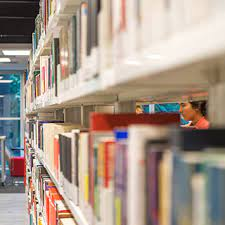

*Fonte: insper.edu.br*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Antes de usar a biblioteca Pandas para lidar com planilhas contendo dados, usamos outro exemplo de biblioteca: a google.colab. Ela possui um módulo chamado drive. Ele é importado na primeira linha do código acima.

Esse módulo, por sua vez, possui uma função chamada 'mount()' que permite acoplar os arquivos do seu Google Drive à ferramenta Colab. Dessa forma, usando Python, conseguimos acessar e editar arquivos do Google Drive.

In [ ]:
import pandas 

pandas.read_csv

In [ ]:
import pandas as pd
mediacao = pd.read_csv('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/mediacao.csv')
mediacao.head(10)

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:2882: DtypeWarning: Columns (6,17,18) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,Empresa,Autor,Estado,Comarca,Vara,Objeto,Proposta_inicial,Proposta1,Proposta2,Ultima_proposta,Prazo_pagamento,Forma_pagamento,Obg_fazer,Prazo_cumprimento,Situação,Status,Contraproposta_autor,Data_acordo,Data_inicio
0,Telecom 3,3971,RJ,FORUM NOVA IGUACU,JUIZADO ESPECIAL CIVEL,FATURAMENTO - CONTESTACAO DE VALORES - COBRANC...,"R$1,500.00","R$1,500.00","R$1,500.00","R$ 1,500.00",20 Dias úteis,ID DEPOSITO JUDICIAL,"Cancelamento de contratos e débitos, e baixa n...",20 Dias úteis,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017
1,Telecom 4,16934,MG,Belo Horizonte - MG,X JUIZADO ESPECIAL CIVEL,Faturamento,"R$1,850.00","R$2,775.00","R$3,700.00","R$ 3,700.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,Cancelamento do contrato e dos débitos em aber...,60 dias corridos,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017
2,Telecom 4,19302,RJ,Duque de Caxias - RJ,III JUIZADO ESPECIAL CIVEL,Manutenção,"R$1,200.00","R$18,000.00","R$2,400.00","R$ 1,200.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,visita técnica para verificação dos para saber...,60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
3,Telecom 2,20208,BA,NaN,5ª VSJE DO CONSUMIDOR,Contrato,"R$1,000.00","R$1,500.00","R$2,000.00","R$ 1,000.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
4,Telecom 2,22082,RN,Natal,NaN,Cobrança,"R$1,250.00","R$1,875.00",NaN,"R$ 1,250.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
5,Telecom 2,18423,MG,Sete Lagoas,2 Vara Cível,Fraude,"R$1,750.00","R$2,625.00","R$3,500.00","R$ 3,500.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
6,Telecom 1,20572,MG,Belo Horizonte - MG,JUIZADO ESPECIAL CIVEL,Fraude subscrição,"R$1,500.00","R$2,250.00","R$3,000.00","R$ 1,500.00",60 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
7,Telecom 2,15985,BA,Guanambi,JUIZADO ESPECIAL CIVEL,Fraude,"R$4,000.00","R$4,000.00",NaN,"R$ 4,000.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,10 de Março de 2017
8,Telecom 2,22348,MG,Formiga,JUIZADO ESPECIAL CIVEL,Cobrança,"R$2,050.00","R$2,775.00","R$4,100.00","R$ 2,050.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,14 de Março de 2017
9,Telecom 2,10671,MG,Águas Formosas,JUIZADO ESPECIAL CIVEL,Fraude,"R$1,850.00","R$2,775.00","R$3,700.00","R$ 1,850.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,14 de Março de 2017


Já a biblioteca Pandas possui diversas funções ligadas à criação, gestão e análise de bancos de dados. Ela é importada na primeira linha do código acima, com o nome 'pd'. 
Uma vez importada, podemos usar suas funções. Uma delas é a função 'read_csv()', que recebe uma string contendo o caminho de um arquivo e devolve um objeto contendo os dados do arquivo. Note que a máquina precisa saber onde está a função 'read_csv()', motivo pelo qual a biblioteca dela é informada antes:

*pd.read_csv()*

Na terceira linha, aplicamos o método 'head()' a esse objeto com os dados do arquivo. Esse método também pertence à biblioteca Pandas. 

Se tentarmos usar as funções de métodos que pertencem a uma biblioteca específica sem antes importá-la, o código resultará em erro.

In [ ]:
mean((2,4,6))

NameError: ignored

A função 'mean()' pertence a outra biblioteca que também já usamos: Numpy. Ela possui diversas funções feitas para realizar cálculos matemáticos e estatísticos.
Antes de usar suas funções, no entanto, precisamos importar a biblioteca.

In [ ]:
import numpy 
numpy.mean((2,4,6))

4.0

Uma alternativa possível é importar exclusivamente a função que pretendemos utilizar, em vez de importar toda a biblioteca.
A vantagem é que se uma função específica foi importada, não precisamos ficar lembrando a máquina sobre a biblioteca à qual essa função pertence.

In [ ]:
from numpy import mean
mean((2,4,6))

4.0

## Pandas <a class="anchor" id="third-bullet"></a>

Nossa tabela será importada de um arquivo no Google Drive, por isso importamos a biblioteca google.colab como em outras vezes. Também importamos a biblioteca Pandas, dando a ela o nome 'pd'. Usaremos muitas funções e métodos dessa biblioteca para importar, explorar e editar dados. Por último, importamos a biblioteca Numpy, também já vista.

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np

A primeira função que usamos da biblioteca Pandas é 'read_csv()'. Como o próprio nome indica, ela é usada para ler as informações de um arquivo .csv e salvá-las em um objeto do tipo dataframe. 

'read_csv()' recebe um argumento obrigatório: o arquivo a ser lido, incluindo o caminho das pastas e subpastas para encontrá-lo. Essa informação é passada em formado de string.

A chamada de 'read_csv()' retorna um objeto do tipo dataframe que salvamos na variável 'nova_base'.  

In [4]:
nova_base = pd.read_csv('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/CDAD1/mediacao.csv')

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:3326: DtypeWarning: Columns (6,17,18) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


Se a tabela de dados que você quer usar está salva em um arquivo Excel, basta usar a função 'read_excel()' do Pandas. Ela funciona de maneira semelhante.

Sempre que importar uma tabela de dados csv ou excel a primeira providência a tomar é explorar os dados para saber quais as colunas dessa tabela, que tipo de informações cada coluna contém, como a informação é apresentada em cada célula e suas variações. 

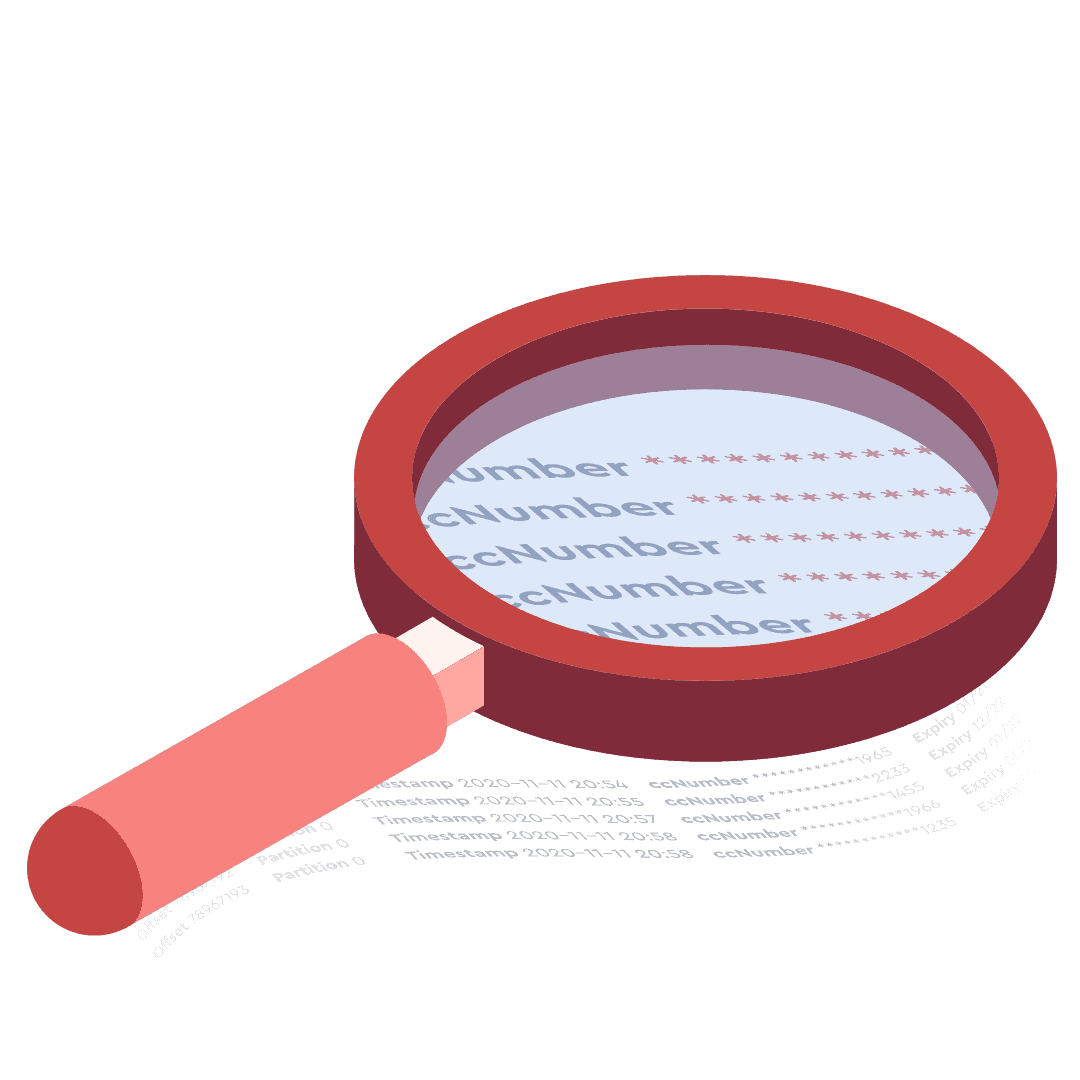

*Fonte: lenses.io*

Existem várias opções no Pandas para a exploração dos dados que foram importados. Essas alternativas são complementares e não excludentes. Uma delas é o método 'head()'. Normalmente a tabela importada possui dezenas, centenas, milhares de linhas e visualizá-la por inteiro na tela é impossível. O que 'head()' oferece é uma maneira rápida de ver as primeiras linhas da tabela para começar a identificar padrões.

In [ ]:
nova_base.head(30)

,Empresa,Autor,Estado,Comarca,Vara,Objeto,Proposta_inicial,Proposta1,Proposta2,Ultima_proposta,Prazo_pagamento,Forma_pagamento,Obg_fazer,Prazo_cumprimento,Situação,Status,Contraproposta_autor,Data_acordo,Data_inicio
0,Telecom 3,3971,RJ,FORUM NOVA IGUACU,JUIZADO ESPECIAL CIVEL,FATURAMENTO - CONTESTACAO DE VALORES - COBRANC...,"R$1,500.00","R$1,500.00","R$1,500.00","R$ 1,500.00",20 Dias úteis,ID DEPOSITO JUDICIAL,"Cancelamento de contratos e débitos, e baixa n...",20 Dias úteis,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017
1,Telecom 4,16934,MG,Belo Horizonte - MG,X JUIZADO ESPECIAL CIVEL,Faturamento,"R$1,850.00","R$2,775.00","R$3,700.00","R$ 3,700.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,Cancelamento do contrato e dos débitos em aber...,60 dias corridos,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017
2,Telecom 4,19302,RJ,Duque de Caxias - RJ,III JUIZADO ESPECIAL CIVEL,Manutenção,"R$1,200.00","R$18,000.00","R$2,400.00","R$ 1,200.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,visita técnica para verificação dos para saber...,60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
3,Telecom 2,20208,BA,NaN,5ª VSJE DO CONSUMIDOR,Contrato,"R$1,000.00","R$1,500.00","R$2,000.00","R$ 1,000.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
4,Telecom 2,22082,RN,Natal,NaN,Cobrança,"R$1,250.00","R$1,875.00",NaN,"R$ 1,250.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
5,Telecom 2,18423,MG,Sete Lagoas,2 Vara Cível,Fraude,"R$1,750.00","R$2,625.00","R$3,500.00","R$ 3,500.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
6,Telecom 1,20572,MG,Belo Horizonte - MG,JUIZADO ESPECIAL CIVEL,Fraude subscrição,"R$1,500.00","R$2,250.00","R$3,000.00","R$ 1,500.00",60 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
7,Telecom 2,15985,BA,Guanambi,JUIZADO ESPECIAL CIVEL,Fraude,"R$4,000.00","R$4,000.00",NaN,"R$ 4,000.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,10 de Março de 2017
8,Telecom 2,22348,MG,Formiga,JUIZADO ESPECIAL CIVEL,Cobrança,"R$2,050.00","R$2,775.00","R$4,100.00","R$ 2,050.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,14 de Março de 2017
9,Telecom 2,10671,MG,Águas Formosas,JUIZADO ESPECIAL CIVEL,Fraude,"R$1,850.00","R$2,775.00","R$3,700.00","R$ 1,850.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,14 de Março de 2017


'head()' retorna uma visualização das primeiras linhas da tabela. Por padrão, são mostradas as primeiras 5 linhas. Se quiser ver as primeiras 10 linhas, é possível chamar 'head()' passando o int 10 como argumento. 

In [ ]:
nova_base.head(10)

,Empresa,Autor,Estado,Comarca,Vara,Objeto,Proposta_inicial,Proposta1,Proposta2,Ultima_proposta,Prazo_pagamento,Forma_pagamento,Obg_fazer,Prazo_cumprimento,Situação,Status,Contraproposta_autor,Data_acordo,Data_inicio
0,Telecom 3,3971,RJ,FORUM NOVA IGUACU,JUIZADO ESPECIAL CIVEL,FATURAMENTO - CONTESTACAO DE VALORES - COBRANC...,"R$1,500.00","R$1,500.00","R$1,500.00","R$ 1,500.00",20 Dias úteis,ID DEPOSITO JUDICIAL,"Cancelamento de contratos e débitos, e baixa n...",20 Dias úteis,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017
1,Telecom 4,16934,MG,Belo Horizonte - MG,X JUIZADO ESPECIAL CIVEL,Faturamento,"R$1,850.00","R$2,775.00","R$3,700.00","R$ 3,700.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,Cancelamento do contrato e dos débitos em aber...,60 dias corridos,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017
2,Telecom 4,19302,RJ,Duque de Caxias - RJ,III JUIZADO ESPECIAL CIVEL,Manutenção,"R$1,200.00","R$18,000.00","R$2,400.00","R$ 1,200.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,visita técnica para verificação dos para saber...,60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
3,Telecom 2,20208,BA,NaN,5ª VSJE DO CONSUMIDOR,Contrato,"R$1,000.00","R$1,500.00","R$2,000.00","R$ 1,000.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
4,Telecom 2,22082,RN,Natal,NaN,Cobrança,"R$1,250.00","R$1,875.00",NaN,"R$ 1,250.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
5,Telecom 2,18423,MG,Sete Lagoas,2 Vara Cível,Fraude,"R$1,750.00","R$2,625.00","R$3,500.00","R$ 3,500.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
6,Telecom 1,20572,MG,Belo Horizonte - MG,JUIZADO ESPECIAL CIVEL,Fraude subscrição,"R$1,500.00","R$2,250.00","R$3,000.00","R$ 1,500.00",60 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
7,Telecom 2,15985,BA,Guanambi,JUIZADO ESPECIAL CIVEL,Fraude,"R$4,000.00","R$4,000.00",NaN,"R$ 4,000.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,10 de Março de 2017
8,Telecom 2,22348,MG,Formiga,JUIZADO ESPECIAL CIVEL,Cobrança,"R$2,050.00","R$2,775.00","R$4,100.00","R$ 2,050.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,14 de Março de 2017
9,Telecom 2,10671,MG,Águas Formosas,JUIZADO ESPECIAL CIVEL,Fraude,"R$1,850.00","R$2,775.00","R$3,700.00","R$ 1,850.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,14 de Março de 2017


Elementos importantes que você deve se acostumar a procurar são:

*Quantas colunas e seus nomes. Note que a visualização gerada por 'head()' mostra a primeira linha como um cabeçalho, destacando os nomes de cada coluna

*Qual o tipo de informação em cada coluna. Trata-se de texto? Números? 

*Células sem preenchimento ou vazias. Isso pode ser algo intencional ou não. Nessa visualização do dataframe 'nova_base' podemos ver que a linha 4 possui células em branco nas colunas 'Vara' e 'Proposta2', por exemplo. Nesse caso, a célula vazia ou valor inexistente é representado por 'NaN'. 

*Células com preenchimento aparentemente incorreto. Pode ser um erro de digitação ou algo mais subjetivo como desvios de padrão. Veja a coluna 'Vara', por exemplo. Faz sentido que todos os demais processos tramitem em uma vara ou juizado e o da linha 4 não? Note também que na linha 2 o número do juizado ou vara é expressado em numerais romanos. Já na linha 3 ele é expressado com um dígito. Essa diferença é necessário ou erro de preenchimento? Por que na linha 3 a vara é a quinta (5a) e na linha 5 a vara é a dois (2)? São desvios de padrão justificáveis? Necessários? Qual deveria ser o preenchimento dessas células para que fosse respeitado um padrão?
Olhe agora para a coluna 'Comarca'. Na linha 4 temos apenas o nome da cidade 'Natal'. Não há informação sobre o estado junto com a cidade. Na linha 1 a informação é 'Belo Horizonte - MG'. Qual delas está seguindo o padrão correto esperado para essa coluna? Para essa coluna, a linha 0 inclui o nome de um foro e não de uma comarca.

Existem tipos de erro que uma análise exploratória da tabela nos permite identificar mesmo sem conhecimento sobre a informação em si. Por outro lado, existem erros menos evidentes. Imagine que a comarca de Sete Lagoas possui apenas uma única vara cível. Isso significa que a informação na célula 'Vara' da linha 5 está errada. Esse erro não seria percebido pela maioria das pessoas. Talvez alguém uma advogada que atua em Sete Lagoas poderia ver a tabela e rapidamente detectar esse erro. Aqui o conhecimento sobre o contexto dos dados já permitiria notar e apontar o erro.
Imagine agora outro tipo de erro, ainda mais difícil de identificar. Digamos que em Sete Lagoas de fato existem duas varas cíveis. E se o processo da linha 5 na verdade tramita na 1a vara cível e não na 2a. Nem a advogada que conhece a comarca de Sete Lagoas teria como saber disso. Esse tipo de erro afeta a integridade da base de dados e só pode ser identificado mediante checagens, cruzamentos de informações e verificações proativas dos dados.

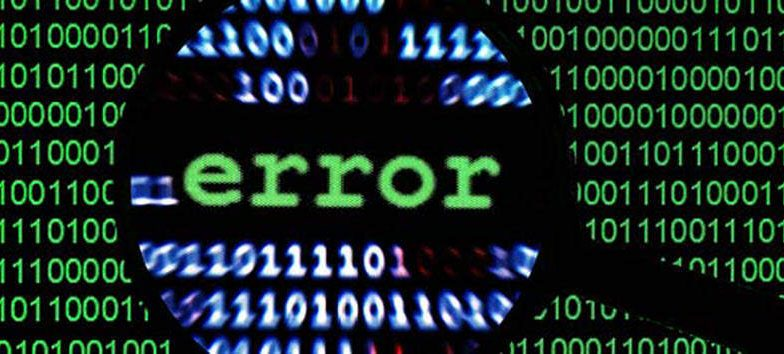

*Fonte: ungerboeck.com*

Vejamos o exemplo da coluna 'Proposta1'. Já havíamos visto essa tabela anteriormente. Sabemos que ela registra tentativas de acordo extrajudicial em casos de direito do consumidor feitas por intermédio de uma lawtech de resolução de disputas online (ODR). 
Uma vez ajuizada a ação pelo consumidor, a lawtech inclui os dados na sua base e permite que a empresa processada faça ofertas para chegar a um acordo. A coluna 'Proposta1' mostra uma oferta feita no início da negociação. Faria sentido que as células dessa coluna estivessem preenchidas com ints ou floats. Note que elas possuem sempre o valor em reais expressado da seguinte maneira: 

R$1,500.00

Sabemos que 'R$' são caracteres impossíveis em um int ou float. Os valores da proposta parecem estar registrados em formato string. Isso significa que não conseguiremos realizar uma operação matemática - como o cálculo da média do valor das propostas - com as informações dessa coluna. 

Objetos do tipo dataframe, como é o caso dessa tabela salva em 'nova_base', possuem um atributo chamado 'dtypes', de data types ou tipos de dados. Os tipos de dados de cada coluna da tabela podem ser mostrados usando esse atributo:

In [ ]:
nova_base.dtypes

Empresa                 object
Autor                    int64
Estado                  object
Comarca                 object
Vara                    object
Objeto                  object
Proposta_inicial        object
Proposta1               object
Proposta2               object
Ultima_proposta         object
Prazo_pagamento         object
Forma_pagamento         object
Obg_fazer               object
Prazo_cumprimento       object
Situação                object
Status                  object
Contraproposta_autor    object
Data_acordo             object
Data_inicio             object
dtype: object

O atributo 'dtypes' mostra que apenas a coluna 'Autor' está identificada como contendo informações em formato int. A coluna 'Proposta1' com certeza não está identificada como uma coluna contendo informações numéricas.
O método 'info()' permite mostrar um sumário de informações sobre o dataframe, incluindo os dtypes.

In [ ]:
nova_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40506 entries, 0 to 40505
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Empresa               40506 non-null  object
 1   Autor                 40506 non-null  int64 
 2   Estado                40438 non-null  object
 3   Comarca               38992 non-null  object
 4   Vara                  36584 non-null  object
 5   Objeto                32917 non-null  object
 6   Proposta_inicial      41 non-null     object
 7   Proposta1             5160 non-null   object
 8   Proposta2             8700 non-null   object
 9   Ultima_proposta       39907 non-null  object
 10  Prazo_pagamento       31435 non-null  object
 11  Forma_pagamento       31165 non-null  object
 12  Obg_fazer             28324 non-null  object
 13  Prazo_cumprimento     28665 non-null  object
 14  Situação              40506 non-null  object
 15  Status                40506 non-null

O método 'info()' mostra várias informações relevantes sobre a tabela. 

A primeira linha confirma que nosso objeto é da classe dataframe.

A segunda linha informa o número de linha na tabela: 40506. 

A terceira linha informa o número de colunas: 19.

Na sequência, cada coluna é apresentada com seu nome, quantia de linhas vazias (célula não preenchida) e o tipo do dado na coluna. Essa terceira informação é o atributo dtype.

Na última linha recebemos a informação sobre o quanto de memória essa tabela ocupa, em razão do seu tamanho em linhas e colunas e em razão da complexidade de seus dados. Armazenar um int de dois dígitos é muito mais simples do que armazenar uma string de 20 caracteres.

**Exemplo de correção de dados em uma coluna**

Vimos, portanto, que a coluna 'Proposta1' possui valores em reais expressados em formato diferente de int. Trata-se de strings.
Se possuímos a seguinte série de dados:

In [ ]:
dados = (3,7,10)
np.mean(dados)

6.666666666666667

É possível e fácil determinar a média de uma série de dados expressados em int.



In [ ]:
'3'+'7'  

'37'

As operações matemáticas não funcionam da mesma forma com strings - a maioria delas sequer é possível.  

In [ ]:
'3'*'7'

TypeError: ignored

Para usar os valores da coluna 'Proposta1', precisamos primeiro transformá-los de texto para números. Poderíamos tentar transformar de string para int. Porém valores em reais podem ter dois dígitos após a vírgula (centavos). Então nosso objetivo é transformá-los de string para float.

Sabemos que isso é possível:

In [ ]:
float('3')

3.0

Antes da transformação, temos um problema a resolver:

In [ ]:
float('R$ 3')

ValueError: ignored

O 'R$' em cada célula precisa ser removido, bem como a vírgula. A idéia é que strings como essa

R$1,750.00

virem strings como essa

1750.00

Uma maneira de remover todos os 'R$' é substituí-los por uma string vazia.

In [ ]:
string = 'R$1,750.00'
string_alterada = string.replace('R$','')
print(string)
print(string_alterada)

R$1,750.00
1,750.00


O método 'replace()' permite fazer trocas dentro de uma string. Ele é aplicado à string que será alterada ou editada. O primeiro argumento é a parte da string que deve ser buscada e removida. O segundo argumento é a string que será colocada no lugar da primeira. Se colocarmos um string vazia como segundo argumento, isso terá como resultado a remoção da string passada no primeiro argumento.

O método 'replace()' funciona da mesma maneira que o comando 'procurar e substituir' do Word.

In [ ]:
string_final = string_alterada.replace(',','')
print(string_final)

Uma das muitas facilidades de nossos dados estarem salvos em um dataframe é que podemos realizar uma operação em todas as células de uma coluna. Para isso, basta realizar a operação ou aplicar o método na coluna desejada. Se para a string isolada tínhamos

string .replace() --->  string nova, alterada

então para colunas do dataframe temos

coluna . replace() ---> coluna nova, alterada

In [5]:
nova_base.Proposta1 = nova_base.Proposta1.str.replace('R$','',regex=False)

'replace()' precisa ser aplicado a uma string. Como vimos acima, o objeto na coluna 'Proposta1' não é necessariamente uma string, então aplicamos 'replace()' à versão string dessa coluna.


Feita a alteração em toda a coluna 'Proposta1', podemos olhar novamente as primeiras linhas do dataframe

In [ ]:
nova_base.head(10)

,Empresa,Autor,Estado,Comarca,Vara,Objeto,Proposta_inicial,Proposta1,Proposta2,Ultima_proposta,Prazo_pagamento,Forma_pagamento,Obg_fazer,Prazo_cumprimento,Situação,Status,Contraproposta_autor,Data_acordo,Data_inicio
0,Telecom 3,3971,RJ,FORUM NOVA IGUACU,JUIZADO ESPECIAL CIVEL,FATURAMENTO - CONTESTACAO DE VALORES - COBRANC...,"R$1,500.00","1,500.00","R$1,500.00","R$ 1,500.00",20 Dias úteis,ID DEPOSITO JUDICIAL,"Cancelamento de contratos e débitos, e baixa n...",20 Dias úteis,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017
1,Telecom 4,16934,MG,Belo Horizonte - MG,X JUIZADO ESPECIAL CIVEL,Faturamento,"R$1,850.00","2,775.00","R$3,700.00","R$ 3,700.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,Cancelamento do contrato e dos débitos em aber...,60 dias corridos,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017
2,Telecom 4,19302,RJ,Duque de Caxias - RJ,III JUIZADO ESPECIAL CIVEL,Manutenção,"R$1,200.00","18,000.00","R$2,400.00","R$ 1,200.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,visita técnica para verificação dos para saber...,60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
3,Telecom 2,20208,BA,NaN,5ª VSJE DO CONSUMIDOR,Contrato,"R$1,000.00","1,500.00","R$2,000.00","R$ 1,000.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
4,Telecom 2,22082,RN,Natal,NaN,Cobrança,"R$1,250.00","1,875.00",NaN,"R$ 1,250.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
5,Telecom 2,18423,MG,Sete Lagoas,2 Vara Cível,Fraude,"R$1,750.00","2,625.00","R$3,500.00","R$ 3,500.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
6,Telecom 1,20572,MG,Belo Horizonte - MG,JUIZADO ESPECIAL CIVEL,Fraude subscrição,"R$1,500.00","2,250.00","R$3,000.00","R$ 1,500.00",60 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
7,Telecom 2,15985,BA,Guanambi,JUIZADO ESPECIAL CIVEL,Fraude,"R$4,000.00","4,000.00",NaN,"R$ 4,000.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,10 de Março de 2017
8,Telecom 2,22348,MG,Formiga,JUIZADO ESPECIAL CIVEL,Cobrança,"R$2,050.00","2,775.00","R$4,100.00","R$ 2,050.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,14 de Março de 2017
9,Telecom 2,10671,MG,Águas Formosas,JUIZADO ESPECIAL CIVEL,Fraude,"R$1,850.00","2,775.00","R$3,700.00","R$ 1,850.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,14 de Março de 2017


Agora as células de 'Proposta1' não possuem 'R$' no início da string.
Vamos substituir as vírgulas por string vazia usando o mesmo método

In [6]:
nova_base.Proposta1 = nova_base.Proposta1.str.replace(',','')

In [ ]:
nova_base.head(10)

,Empresa,Autor,Estado,Comarca,Vara,Objeto,Proposta_inicial,Proposta1,Proposta2,Ultima_proposta,Prazo_pagamento,Forma_pagamento,Obg_fazer,Prazo_cumprimento,Situação,Status,Contraproposta_autor,Data_acordo,Data_inicio
0,Telecom 3,3971,RJ,FORUM NOVA IGUACU,JUIZADO ESPECIAL CIVEL,FATURAMENTO - CONTESTACAO DE VALORES - COBRANC...,"R$1,500.00",1500.00,"R$1,500.00","R$ 1,500.00",20 Dias úteis,ID DEPOSITO JUDICIAL,"Cancelamento de contratos e débitos, e baixa n...",20 Dias úteis,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017
1,Telecom 4,16934,MG,Belo Horizonte - MG,X JUIZADO ESPECIAL CIVEL,Faturamento,"R$1,850.00",2775.00,"R$3,700.00","R$ 3,700.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,Cancelamento do contrato e dos débitos em aber...,60 dias corridos,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017
2,Telecom 4,19302,RJ,Duque de Caxias - RJ,III JUIZADO ESPECIAL CIVEL,Manutenção,"R$1,200.00",18000.00,"R$2,400.00","R$ 1,200.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,visita técnica para verificação dos para saber...,60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
3,Telecom 2,20208,BA,NaN,5ª VSJE DO CONSUMIDOR,Contrato,"R$1,000.00",1500.00,"R$2,000.00","R$ 1,000.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
4,Telecom 2,22082,RN,Natal,NaN,Cobrança,"R$1,250.00",1875.00,NaN,"R$ 1,250.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
5,Telecom 2,18423,MG,Sete Lagoas,2 Vara Cível,Fraude,"R$1,750.00",2625.00,"R$3,500.00","R$ 3,500.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
6,Telecom 1,20572,MG,Belo Horizonte - MG,JUIZADO ESPECIAL CIVEL,Fraude subscrição,"R$1,500.00",2250.00,"R$3,000.00","R$ 1,500.00",60 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
7,Telecom 2,15985,BA,Guanambi,JUIZADO ESPECIAL CIVEL,Fraude,"R$4,000.00",4000.00,NaN,"R$ 4,000.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,10 de Março de 2017
8,Telecom 2,22348,MG,Formiga,JUIZADO ESPECIAL CIVEL,Cobrança,"R$2,050.00",2775.00,"R$4,100.00","R$ 2,050.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,14 de Março de 2017
9,Telecom 2,10671,MG,Águas Formosas,JUIZADO ESPECIAL CIVEL,Fraude,"R$1,850.00",2775.00,"R$3,700.00","R$ 1,850.00",30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,14 de Março de 2017


Agora só resta transformar as strings já formatadas de 'Proposta1' em float.

In [7]:
nova_base.Proposta1 = nova_base.Proposta1.astype('float')
nova_base.dtypes

Empresa                  object
Autor                     int64
Estado                   object
Comarca                  object
Vara                     object
Objeto                   object
Proposta_inicial         object
Proposta1               float64
Proposta2                object
Ultima_proposta          object
Prazo_pagamento          object
Forma_pagamento          object
Obg_fazer                object
Prazo_cumprimento        object
Situação                 object
Status                   object
Contraproposta_autor     object
Data_acordo              object
Data_inicio              object
dtype: object

Vamos repetir as mesmas etapas para consertar os dados na columa 'Ultima_proposta'.

In [8]:
nova_base.Ultima_proposta = nova_base.Ultima_proposta.str.replace('R$','',regex=False).str.replace(',','',regex=False)
nova_base.Ultima_proposta = nova_base.Ultima_proposta.astype('float')


In [9]:
nova_base.head(20)

,Empresa,Autor,Estado,Comarca,Vara,Objeto,Proposta_inicial,Proposta1,Proposta2,Ultima_proposta,Prazo_pagamento,Forma_pagamento,Obg_fazer,Prazo_cumprimento,Situação,Status,Contraproposta_autor,Data_acordo,Data_inicio
0,Telecom 3,3971,RJ,FORUM NOVA IGUACU,JUIZADO ESPECIAL CIVEL,FATURAMENTO - CONTESTACAO DE VALORES - COBRANC...,"R$1,500.00",1500.0,"R$1,500.00",1500.0,20 Dias úteis,ID DEPOSITO JUDICIAL,"Cancelamento de contratos e débitos, e baixa n...",20 Dias úteis,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017
1,Telecom 4,16934,MG,Belo Horizonte - MG,X JUIZADO ESPECIAL CIVEL,Faturamento,"R$1,850.00",2775.0,"R$3,700.00",3700.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,Cancelamento do contrato e dos débitos em aber...,60 dias corridos,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017
2,Telecom 4,19302,RJ,Duque de Caxias - RJ,III JUIZADO ESPECIAL CIVEL,Manutenção,"R$1,200.00",18000.0,"R$2,400.00",1200.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,visita técnica para verificação dos para saber...,60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
3,Telecom 2,20208,BA,NaN,5ª VSJE DO CONSUMIDOR,Contrato,"R$1,000.00",1500.0,"R$2,000.00",1000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
4,Telecom 2,22082,RN,Natal,NaN,Cobrança,"R$1,250.00",1875.0,NaN,1250.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
5,Telecom 2,18423,MG,Sete Lagoas,2 Vara Cível,Fraude,"R$1,750.00",2625.0,"R$3,500.00",3500.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
6,Telecom 1,20572,MG,Belo Horizonte - MG,JUIZADO ESPECIAL CIVEL,Fraude subscrição,"R$1,500.00",2250.0,"R$3,000.00",1500.0,60 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
7,Telecom 2,15985,BA,Guanambi,JUIZADO ESPECIAL CIVEL,Fraude,"R$4,000.00",4000.0,NaN,4000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,10 de Março de 2017
8,Telecom 2,22348,MG,Formiga,JUIZADO ESPECIAL CIVEL,Cobrança,"R$2,050.00",2775.0,"R$4,100.00",2050.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,14 de Março de 2017
9,Telecom 2,10671,MG,Águas Formosas,JUIZADO ESPECIAL CIVEL,Fraude,"R$1,850.00",2775.0,"R$3,700.00",1850.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,14 de Março de 2017


**Explorando o dataframe**

Além do método 'head()' para ver o início ou primeiras linhas da tabela, também podemos usar o método 'tail()' para ver o final ou últimas linhas. 

In [ ]:
nova_base.tail()

,Empresa,Autor,Estado,Comarca,Vara,Objeto,Proposta_inicial,Proposta1,Proposta2,Ultima_proposta,Prazo_pagamento,Forma_pagamento,Obg_fazer,Prazo_cumprimento,Situação,Status,Contraproposta_autor,Data_acordo,Data_inicio
40501,Saúde,6130,BA,SALVADOR,0 VARA CÍVEL DE SALVADOR,CANCELAMENTO,NaN,NaN,NaN,1000.0,30 DIAS CORRIDOS,DEPÓSITO NA CONTA CORRENTE DO AUTOR,O valor a ser pago referese apenas aos honorár...,30 DIAS CORRIDOS,Sem acordo/ Proposta inferior,Sem Acordo,NaN,NaN,43374
40502,Saúde,19279,BA,SALVADOR,0 VARA CÍVEL DE SALVADOR,DEFEITO DE SERVIÇO/PRODUT,NaN,NaN,NaN,8000.0,30 DIAS CORRIDOS,DEPÓSITO NA CONTA CORRENTE DO AUTOR,NaN,NaN,Sem acordo / Ausência de resposta,Sem Acordo,NaN,43405.0,43374
40503,Saúde,6130,BA,SALVADOR,8 VARA CÍVEL DE SALVADOR,CREDENCIAMENTO,NaN,NaN,NaN,4500.0,30 DIAS CORRIDOS,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"Do valor pago R$1.500,00 referem se a honorári...",NaN,Sem acordo / Ausência de resposta,Sem Acordo,NaN,43405.0,43374
40504,Saúde,14161,BA,SALVADOR,1 JUIZADO ESPECIAL CÍVEL DE SALVADOR,INDEFERIMENTO ANÁLISE TÉCNICA,NaN,NaN,NaN,10000.0,30 DIAS CORRIDOS,DEPÓSITO NA CONTA CORRENTE DO AUTOR,Confirmar a tutela antecipada deferida,30 DIAS CORRIDOS,Acordo Fechado  Houve desistência do acordo p...,Acordo Fechado,NaN,43405.0,43374
40505,Saúde,3789,BA,WENCESLAU GUIMARÃES,0 VARA ÚNICA DA COMARCA DE WENCESLAU GUIMARÃES,NEGATIVA SPC/SERASA,NaN,6000.0,NaN,6000.0,30 DIAS CORRIDOS,DEPÓSITO NA CONTA CORRENTE DO AUTOR,NaN,NaN,Sem acordo / Ausência de resposta,Sem Acordo,NaN,43405.0,43374


Vimos já duas diferenças possíveis nos dados das colunas do dataframe.

Algumas colunas possuem textos, outras possuem números. As colunas com informações numéricas geralmente guardam variáveis númericas. O valor da proposta 1 é uma variável númerica. **Variáveis numéricas** podem ser usadas para finalidades que as variáveis não numéricas não podem. Com variáveis númericas podemos calcular medidas de tendência central como média e mediana e também para calcular desvio padrão. 

In [ ]:
nova_base.Proposta1.mean()

1599.5906976744186

Podemos usar o método 'mean()' aplicado a uma coluna do dataframe para obter a médio dos valores númericos nessa coluna inteira.

In [ ]:
nova_base.Proposta1.std()

893.8174383042536

Também podemos calcular o desvio padrão ou variabilidade do valor da proposta 1 na coluna inteira.

Em outras colunas é possível ver que a informação guardada não é uma variável numérica. A coluna 'Empresa' guarda informações textuais. Trata-se do tipo ou classificação da empresa que está oferecendo o acordo. A coluna 'Empresa' guarda uma **variável categórica** ou não-numérica. Variáveis numéricas podem ser quantificadas. Variáveis categóricas não podem ser quantificadas. Não é possível, por exemplo, calcular a média da coluna 'Empresa'. Outro exemplo:  

In [ ]:
nova_base.Proposta1.max()

18000.0

A variável da coluna 'Proposta1' é numérica e possui um valor máximo e um valor mínimo. O método 'max()' aplicado à coluna devolve o conteúdo da célula com o valor mais alto de 'Proposta1' em todas as 40506 linhas. A proposta 1 mais alta feita é de 18 mil reais. Você consegue imaginar o que o método 'min()' retorna?

Não faz sentido perguntar, por outro lado, qual é o valor mais alto de 'Empresa'. Para variáveis categóricas uma das informações mais importantes a se obter é a lista de opções ou alternativas. Queremos saber todas as maneiras diferentes que 'Empresa' pode assumir. Quais os tipos diferentes de empresa?

In [ ]:
nova_base.Empresa.unique()

array(['Telecom 3', 'Telecom 4', 'Telecom 2', 'Telecom 1',
       'Eletrodomésticos', 'Saúde', 'Infra', 'Cosméticos'], dtype=object)

O método 'unique()' devolve uma série de dados contendo a string de cada forma diferente mediante a qual a coluna 'Empresa' pode estar preenchida.

Esse iterável pode ser usado para fazer um for loop sobre cada categoria diferente da coluna 'Empresa'.

In [10]:
for categoria in nova_base.Empresa.unique():
  dados = nova_base.Proposta1[nova_base.Empresa == categoria]
  print('A média do valor da proposta 1 para empresas do setor de '+categoria+' é de R$ '+str(dados.median()))

A média do valor da proposta 1 para empresas do setor de Telecom 3 é de R$ 1500.0
A média do valor da proposta 1 para empresas do setor de Telecom 4 é de R$ 10387.5
A média do valor da proposta 1 para empresas do setor de Telecom 2 é de R$ 2721.0
A média do valor da proposta 1 para empresas do setor de Telecom 1 é de R$ 1179.0
A média do valor da proposta 1 para empresas do setor de Eletrodomésticos é de R$ 1300.0
A média do valor da proposta 1 para empresas do setor de Saúde é de R$ 4000.0
A média do valor da proposta 1 para empresas do setor de Infra é de R$ 900.0
A média do valor da proposta 1 para empresas do setor de Cosméticos é de R$ nan


/usr/local/lib/python3.7/dist-packages/numpy/lib/nanfunctions.py:1117: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Com 'unique()' podemos saber quais são as categorias diferentes ou únicas na coluna 'Empresa' ou qualquer outra. É importante também saber quantos processos ou linhas existem para cada tipo de empresa. 

In [11]:
nova_base['Empresa'].value_counts()

Telecom 1           20892
Telecom 2            6849
Infra                6266
Telecom 3            5008
Saúde                1201
Telecom 4             205
Cosméticos             73
Eletrodomésticos       12
Name: Empresa, dtype: int64

O método 'value_counts()' retorna as contagens ou totais de linhas de cada categoria diferente na coluna escolhida.
Outra variável categórica na base está na coluna 'Estado'. 

In [ ]:
nova_base.Estado.value_counts()

RJ                22508
MG                11470
ES                 1762
SP                 1759
BA                  826
PE                  522
RN                  382
MA                  230
CE                  142
AL                  134
PB                  132
PA                  122
AM                  117
PI                   76
SE                   40
PR                   38
RR                   35
GO                   34
RIO DE JANEIRO       21
AP                   20
SC                   19
MT                   15
RS                   15
DF                   11
MS                    3
TO                    2
RO                    2
AC                    1
Name: Estado, dtype: int64

Podemos ver que existem 22508 linhas ou processos do estado do Rio de Janeiro e apenas 15 linhas ou processos do estado do Rio Grande do Sul. Isso é um indicativo dos estados nos quais a lawtech de acordos online tem maior presença.

Outra coluna que parece conter uma variável categórica é a 'Status'.

In [ ]:
nova_base.Status.value_counts()

Sem Acordo                   24023
Acordo Fechado                7510
Caso devolvido pra equipe     6665
Em negociação                 2299
acordo Fechado                   8
ACordo Fechado                   1
Name: Status, dtype: int64

O método 'value_counts()' pode receber o argumento 'normalize' com valor 'True' para que no lugar no número de linhas seja apresentada proporção de linhas da categoria diante da coluna inteira.

In [ ]:
nova_base.Status.value_counts(normalize=True)

Sem Acordo                   0.593073
Acordo Fechado               0.185405
Caso devolvido pra equipe    0.164544
Em negociação                0.056757
acordo Fechado               0.000198
ACordo Fechado               0.000025
Name: Status, dtype: float64

Ou seja, 59% das linhas ou processos ficaram sem acordo. Ou seria um taxa maior? Note que existem linhas nas quais a coluna 'Status' contém a informação sobre acordo realizado escrita de maneira diferente de 'Acordo Fechado'. Em 8 linhas a string é 'acordo Fechado'. Em 1 linha é 'ACordo Fechado'. Isso provavelmente resulta de erros de digitação e preenchimento cometidos pelas pessoas que introduziram os dados dos casos nessa base. 
Vamos realizar a correção como já havíamos feito com a coluna 'Proposta1'.  

In [ ]:
nova_base.Status = nova_base.Status.replace('acordo Fechado','Acordo Fechado')
nova_base.Status = nova_base.Status.replace('ACordo Fechado','Acordo Fechado')
nova_base.Status.value_counts(normalize=True)

Sem Acordo                   0.593073
Acordo Fechado               0.185627
Caso devolvido pra equipe    0.164544
Em negociação                0.056757
Name: Status, dtype: float64

In [13]:
nova_base['nova coluna'] = nova_base.Status.replace('acordo Fechado','Acordo Fechado')

In [19]:
nova_base['mais uma coluna'] = nova_base.Comarca.str.replace(' - ','')

In [21]:
nova_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40506 entries, 0 to 40505
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Empresa               40506 non-null  object 
 1   Autor                 40506 non-null  int64  
 2   Estado                40438 non-null  object 
 3   Comarca               38992 non-null  object 
 4   Vara                  36584 non-null  object 
 5   Objeto                32917 non-null  object 
 6   Proposta_inicial      41 non-null     object 
 7   Proposta1             5160 non-null   float64
 8   Proposta2             8700 non-null   object 
 9   Ultima_proposta       39907 non-null  float64
 10  Prazo_pagamento       31435 non-null  object 
 11  Forma_pagamento       31165 non-null  object 
 12  Obg_fazer             28324 non-null  object 
 13  Prazo_cumprimento     28665 non-null  object 
 14  Situação              40506 non-null  object 
 15  Status             

In [20]:
nova_base.head()

,Empresa,Autor,Estado,Comarca,Vara,Objeto,Proposta_inicial,Proposta1,Proposta2,Ultima_proposta,...,Forma_pagamento,Obg_fazer,Prazo_cumprimento,Situação,Status,Contraproposta_autor,Data_acordo,Data_inicio,nova coluna,mais uma coluna
0,Telecom 3,3971,RJ,FORUM NOVA IGUACU,JUIZADO ESPECIAL CIVEL,FATURAMENTO - CONTESTACAO DE VALORES - COBRANC...,"R$1,500.00",1500.0,"R$1,500.00",1500.0,...,ID DEPOSITO JUDICIAL,"Cancelamento de contratos e débitos, e baixa n...",20 Dias úteis,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017,Sem Acordo,FORUM NOVA IGUACU
1,Telecom 4,16934,MG,Belo Horizonte - MG,X JUIZADO ESPECIAL CIVEL,Faturamento,"R$1,850.00",2775.0,"R$3,700.00",3700.0,...,DEPÓSITO NA CONTA CORRENTE DO AUTOR,Cancelamento do contrato e dos débitos em aber...,60 dias corridos,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017,Sem Acordo,Belo HorizonteMG
2,Telecom 4,19302,RJ,Duque de Caxias - RJ,III JUIZADO ESPECIAL CIVEL,Manutenção,"R$1,200.00",18000.0,"R$2,400.00",1200.0,...,DEPÓSITO NA CONTA CORRENTE DO AUTOR,visita técnica para verificação dos para saber...,60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017,Sem Acordo,Duque de CaxiasRJ
3,Telecom 2,20208,BA,NaN,5ª VSJE DO CONSUMIDOR,Contrato,"R$1,000.00",1500.0,"R$2,000.00",1000.0,...,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017,Sem Acordo,NaN
4,Telecom 2,22082,RN,Natal,NaN,Cobrança,"R$1,250.00",1875.0,NaN,1250.0,...,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017,Sem Acordo,Natal


Agora nossa variável categórica 'Status' está corretamente preenchida. Continuamos com menos de 60% de taxa de sucesso na mediação. O que isso diz sobre a eficiência da lawtech?

Apenas 18% dos processos resultaram em acordo.

Uma vez que nossa base de dados esteja salva como dataframe, existem explorações, checagens, testes, correções etc que podemos querer fazer em *toda* a tabela e existem também situações nas quais queremos usar apenas uma parte da tabela.

Por exemplo, talvez nosso interesse seja especificamente em uma das colunas. Podemos salvar toda uma coluna específica em uma nova variável.



In [ ]:
empresas_base = nova_base.Empresa
print(empresas_base)

0        Telecom 3
1        Telecom 4
2        Telecom 4
3        Telecom 2
4        Telecom 2
           ...    
40501        Saúde
40502        Saúde
40503        Saúde
40504        Saúde
40505        Saúde
Name: Empresa, Length: 40506, dtype: object


In [ ]:
empresas_base.head(15)

0            Telecom 3
1            Telecom 4
2            Telecom 4
3            Telecom 2
4            Telecom 2
5            Telecom 2
6            Telecom 1
7            Telecom 2
8            Telecom 2
9            Telecom 2
10           Telecom 2
11           Telecom 2
12           Telecom 2
13           Telecom 2
14    Eletrodomésticos
Name: Empresa, dtype: object

Nossa variável 'empresas_base' contém toda a coluna 'Empresa'. Podemos visualizar a coluna ou partes dela, usando print() ou head(). Podemos fazer alguma alteração em cada linha de 'empresas_base'. 

In [ ]:
empresas_base = empresas_base.str.replace('Telecom','Empresa de Telecomunicações')

Lembra que estamos lidando agora com um objeto separado do dataframe. Ao alterar o conteúdo de 'empresas_base' não estamos tocando na coluna 'Empresa' do dataframe salvo em 'nova_base'. 
Veja: 

In [ ]:
empresas_base.head(20)

0     Empresa de Telecomunicações 3
1     Empresa de Telecomunicações 4
2     Empresa de Telecomunicações 4
3     Empresa de Telecomunicações 2
4     Empresa de Telecomunicações 2
5     Empresa de Telecomunicações 2
6     Empresa de Telecomunicações 1
7     Empresa de Telecomunicações 2
8     Empresa de Telecomunicações 2
9     Empresa de Telecomunicações 2
10    Empresa de Telecomunicações 2
11    Empresa de Telecomunicações 2
12    Empresa de Telecomunicações 2
13    Empresa de Telecomunicações 2
14                 Eletrodomésticos
15                 Eletrodomésticos
16                 Eletrodomésticos
17                 Eletrodomésticos
18    Empresa de Telecomunicações 2
19    Empresa de Telecomunicações 2
Name: Empresa, dtype: object

In [ ]:
nova_base.Empresa.head(20)

0            Telecom 3
1            Telecom 4
2            Telecom 4
3            Telecom 2
4            Telecom 2
5            Telecom 2
6            Telecom 1
7            Telecom 2
8            Telecom 2
9            Telecom 2
10           Telecom 2
11           Telecom 2
12           Telecom 2
13           Telecom 2
14    Eletrodomésticos
15    Eletrodomésticos
16    Eletrodomésticos
17    Eletrodomésticos
18           Telecom 2
19           Telecom 2
Name: Empresa, dtype: object

Em determinadas situações, talvez seja necessário iterar sobre cada linha de 'empresas_base'. 

In [ ]:
for linha in empresas_base[:10]:
  print(linha)

print('\n\n Próximo for loop: \n\n')

for linha in empresas_base[:10]:
  numero = linha[-1]
  print('Nessa linha temos a empresa de telecom de número',numero,'da base de dados')

Empresa de Telecomunicações 3
Empresa de Telecomunicações 4
Empresa de Telecomunicações 4
Empresa de Telecomunicações 2
Empresa de Telecomunicações 2
Empresa de Telecomunicações 2
Empresa de Telecomunicações 1
Empresa de Telecomunicações 2
Empresa de Telecomunicações 2
Empresa de Telecomunicações 2


 Próximo for loop: 


Nessa linha temos a empresa de telecom de número 3 da base de dados
Nessa linha temos a empresa de telecom de número 4 da base de dados
Nessa linha temos a empresa de telecom de número 4 da base de dados
Nessa linha temos a empresa de telecom de número 2 da base de dados
Nessa linha temos a empresa de telecom de número 2 da base de dados
Nessa linha temos a empresa de telecom de número 2 da base de dados
Nessa linha temos a empresa de telecom de número 1 da base de dados
Nessa linha temos a empresa de telecom de número 2 da base de dados
Nessa linha temos a empresa de telecom de número 2 da base de dados
Nessa linha temos a empresa de telecom de número 2 da base de da

Podemos extrair e salvar uma coluna inteira da base, mas podemos extrair apenas uma parte da coluna - algumas das linhas, segundo algum criterio.

Você deve ter notado anteriormente quando iteramos pelas categorias da coluna 'Empresa' que um slice foi feito de apenas parte das linhas de uma determinada coluna segundo algum critério. O código era:

In [ ]:
for categoria in nova_base.Empresa.unique():
  dados = nova_base.Proposta1[nova_base.Empresa == categoria]
  print('A média do valor da proposta 1 para empresas do setor de '+categoria+' é de R$ '+str(dados.mean()))

A média do valor da proposta 1 para empresas do setor de Telecom 3 é de R$ 1500.0
A média do valor da proposta 1 para empresas do setor de Telecom 4 é de R$ 10387.5
A média do valor da proposta 1 para empresas do setor de Telecom 2 é de R$ 2619.0
A média do valor da proposta 1 para empresas do setor de Telecom 1 é de R$ 1575.287703471269
A média do valor da proposta 1 para empresas do setor de Eletrodomésticos é de R$ 1222.7272727272727
A média do valor da proposta 1 para empresas do setor de Saúde é de R$ 4635.294117647059
A média do valor da proposta 1 para empresas do setor de Infra é de R$ 1150.0
A média do valor da proposta 1 para empresas do setor de Cosméticos é de R$ nan


In [ ]:
nova_base.Empresa.unique()

array(['Telecom 3', 'Telecom 4', 'Telecom 2', 'Telecom 1',
       'Eletrodomésticos', 'Saúde', 'Infra', 'Cosméticos'], dtype=object)

 Obter uma parte das linhas de uma coluna segundo algum critério ou condição é outra ferramenta poderosa da biblioteca Pandas.

In [ ]:
proposta_sem_acordo = nova_base.Ultima_proposta[nova_base.Status == 'Sem Acordo']

In [36]:
len(nova_base.Proposta1[(nova_base.Estado=='SP') & (nova_base.Estado=='ES')])

0

Salvamos na variável 'proposta_sem_acordo' todos os valores de 'Ultima_proposta' para os processos que resultaram 'Sem Acordo'.

In [ ]:
proposta_sem_acordo.head()

0    1500.0
1    3700.0
2    1200.0
3    1000.0
4    1250.0
Name: Ultima_proposta, dtype: float64

Com 'head()', podemos ver os primeiros valores dos processos sem acordo. 

Será que a média do valor proposto nesses processos é similar à media do valor proposto nos processos em que o consumidor aceitou a proposta e o acordo teve sucesso?

In [ ]:
proposta_com_acordo = nova_base.Ultima_proposta[nova_base.Status == 'Acordo Fechado']

print('O valor médio da proposta quando há acordo é de',proposta_com_acordo.mean())
print('O valor médio da proposta quando não há acordo é de',proposta_sem_acordo.mean())

O valor médio da proposta quando há acordo é de 2627.13987595038
O valor médio da proposta quando não há acordo é de 2395.5494341870162


Podemos recortar uma partes das linhas de uma coluna específica ou uma parte das linhas de todo o dataframe

Slice para obter linhas de uma única coluna:

**dataframe.coluna[dataframe.coluna segundo alguma condição]**

Slice para obter linhas do dataframe inteiro:

**dataframe[dataframe.coluna segundo alguma condição]**

A diferença está na parte fora dos colchetes. Se quero obter algumas linhas específicas de uma coluna, será *dataframe.coluna*
Se quero obter algumas linhas específicas para todas as colunas do dataframe, será *dataframe*

Veja a diferença abaixo.

In [ ]:
casos_SP = nova_base.Estado[nova_base.Estado == 'SP']
casos_SP.head()

16    SP
38    SP
39    SP
40    SP
41    SP
Name: Estado, dtype: object

In [ ]:
base_inteira_casos_SP = nova_base[nova_base.Estado == 'SP']
base_inteira_casos_SP.head()

,Empresa,Autor,Estado,Comarca,Vara,Objeto,Proposta_inicial,Proposta1,Proposta2,Ultima_proposta,Prazo_pagamento,Forma_pagamento,Obg_fazer,Prazo_cumprimento,Situação,Status,Contraproposta_autor,Data_acordo,Data_inicio
16,Eletrodomésticos,18450,SP,MATAO,JUIZADO ESPECIAL CIVEL,Danos Morais; Ressarcimento,R$500.00,1000.0,"R$1,300.00",1300.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,TROCA DO FOGÃO MODELO 76SBR OU O RESSARCIMENTO...,30 dias úteis,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,24 de Março de 2017
38,Saúde,16800,SP,SAO PAULO,14ª VARA CIVEL,NEGATIVA COBERTURA,NaN,NaN,"R$ 4.000,00",4000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,CONFIRMAR A LIMINAR DESDE QUE EM REDE CREDENCIADA,15 dias úteis,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,12 de Maio de 2017
39,Telecom 2,11208,SP,São Paulo,2 Vara Cível,Contrato,NaN,NaN,"R$ 4.300,00",4300.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,Cancelamento de todo o débito relacionado no o...,30 dias corridos,Acordo Fechado  Minuta enviada para a equipe,Acordo Fechado,NaN,12 DE SETEMBRO DE 2017,01 de Setembro de 2017
40,Saúde,2147,SP,SÃO PAULO,VARA CIVEL,NEGATIVA DE COBERTURA,NaN,NaN,"R$ 6.000,00",6000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,autorizar e custear as despesas de internação ...,15 dias úteis,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,12 de Maio de 2017
41,Saúde,11785,SP,ATIBAIA,3ª VARA CIVEL,NEGATIVA COBERTURA,NaN,NaN,"R$ 4.000,00",4000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,CONFIRMAR A LIMINAR DESDE QUE EM REDE CREDENCIADA,15 dias úteis,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,12 de Maio de 2017


A diferença entre casos_SP e base_inteira_casos_SP é no número de colunas. Mas as duas possuem exatamente o mesmo número de linhas.

In [ ]:
len(casos_SP) == len(base_inteira_casos_SP)

True

Podemos querer extrair um conjunto de linhas *de uma coluna* segundo um critério ou condição aplicado *a outra(s) coluna(s)*. 

In [ ]:
ultima_proposta_telecom_SP = nova_base.Ultima_proposta[(nova_base.Estado == 'SP') & (nova_base.Empresa.str.match(r'Telecom\s\d'))]

In [ ]:
print("O total de linhas que preenche a condição Estado == 'SP' **E** dá match com a expressão regular r'Telecom\s\d' é",len(ultima_proposta_telecom_SP))
ultima_proposta_telecom_SP.head(20)


O total de linhas que preenche a condição Estado == 'SP' **E** dá match com a expressão regular r'Telecom\s\d' é 1250


39     4300.0
125    1700.0
128    3100.0
129    2200.0
168    4000.0
203    4000.0
210    4000.0
214    3100.0
312    4300.0
321    3500.0
357    2500.0
402    3200.0
403    1100.0
404    1600.0
421    2500.0
430    3500.0
440    3500.0
448    4000.0
487    4000.0
488    4000.0
Name: Ultima_proposta, dtype: float64

As condições nas diferentes colunas podem ser cumulativas ('&') ou alternativas ('|').

In [ ]:
propostas_maiores_2500_ou_sem_acordo = nova_base[(nova_base.Proposta1 > 2500) | (nova_base.Status == 'Sem Acordo')]
propostas_maiores_2500_ou_sem_acordo.head(20)

,Empresa,Autor,Estado,Comarca,Vara,Objeto,Proposta_inicial,Proposta1,Proposta2,Ultima_proposta,Prazo_pagamento,Forma_pagamento,Obg_fazer,Prazo_cumprimento,Situação,Status,Contraproposta_autor,Data_acordo,Data_inicio
0,Telecom 3,3971,RJ,FORUM NOVA IGUACU,JUIZADO ESPECIAL CIVEL,FATURAMENTO - CONTESTACAO DE VALORES - COBRANC...,"R$1,500.00",1500.0,"R$1,500.00",1500.0,20 Dias úteis,ID DEPOSITO JUDICIAL,"Cancelamento de contratos e débitos, e baixa n...",20 Dias úteis,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017
1,Telecom 4,16934,MG,Belo Horizonte - MG,X JUIZADO ESPECIAL CIVEL,Faturamento,"R$1,850.00",2775.0,"R$3,700.00",3700.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,Cancelamento do contrato e dos débitos em aber...,60 dias corridos,Sem acordo / Ausência de resposta,Sem Acordo,NaN,NaN,06 de Março de 2017
2,Telecom 4,19302,RJ,Duque de Caxias - RJ,III JUIZADO ESPECIAL CIVEL,Manutenção,"R$1,200.00",18000.0,"R$2,400.00",1200.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,visita técnica para verificação dos para saber...,60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
3,Telecom 2,20208,BA,NaN,5ª VSJE DO CONSUMIDOR,Contrato,"R$1,000.00",1500.0,"R$2,000.00",1000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
4,Telecom 2,22082,RN,Natal,NaN,Cobrança,"R$1,250.00",1875.0,NaN,1250.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
5,Telecom 2,18423,MG,Sete Lagoas,2 Vara Cível,Fraude,"R$1,750.00",2625.0,"R$3,500.00",3500.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
6,Telecom 1,20572,MG,Belo Horizonte - MG,JUIZADO ESPECIAL CIVEL,Fraude subscrição,"R$1,500.00",2250.0,"R$3,000.00",1500.0,60 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAR DÉBITOS, EXCLUIR O CONTRATO E RETIRAR...",60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,06 de Março de 2017
7,Telecom 2,15985,BA,Guanambi,JUIZADO ESPECIAL CIVEL,Fraude,"R$4,000.00",4000.0,NaN,4000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,10 de Março de 2017
8,Telecom 2,22348,MG,Formiga,JUIZADO ESPECIAL CIVEL,Cobrança,"R$2,050.00",2775.0,"R$4,100.00",2050.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,14 de Março de 2017
9,Telecom 2,10671,MG,Águas Formosas,JUIZADO ESPECIAL CIVEL,Fraude,"R$1,850.00",2775.0,"R$3,700.00",1850.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"CANCELAMENTO DE CONTRATO, DÉBITOS E NEGATIVAÇÃO",30 DIAS CORRIDOS,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,14 de Março de 2017


In [ ]:
teste = propostas_maiores_2500_ou_sem_acordo[propostas_maiores_2500_ou_sem_acordo.Status != 'Sem Acordo']
teste.head(20) 

,Empresa,Autor,Estado,Comarca,Vara,Objeto,Proposta_inicial,Proposta1,Proposta2,Ultima_proposta,Prazo_pagamento,Forma_pagamento,Obg_fazer,Prazo_cumprimento,Situação,Status,Contraproposta_autor,Data_acordo,Data_inicio
101,Saúde,5199,PE,RECIFE,2ª VARA CÍVEL,NEGATIVA DE COBERTURA,3000,3600.0,"R$ 4.000,00",4000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,RATIFICAR OS TERMOS DA TUTELA DE URGÊNCIA,20 Dias corridos,Caso devolvido / já teve acordo,Caso devolvido pra equipe,NaN,NaN,03 de Julho de 2017
156,Saúde,12280,RJ,CAPITAL,2 JUIZADO ESPECIAL CÍVEL DE RIO DE JANEIRO,CANCELAMENTO PF,NaN,3000.0,"R$ 4.000,00",5000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,CANCELAR CONTRATO E TODO E QUALQUER DÍVIDA E R...,15 dias úteis,Caso devolvido / já teve sentença,Caso devolvido pra equipe,NaN,NaN,10 de Julho de 2017
163,Saúde,510,PR,LONDRINA,3 JUIZADO ESPECIAL CÍVEL DE LONDRINA,NaN,4000,5000.0,"R$ 6.000,00",6000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,Confirmar a tutela para ré garanta a cobertura...,15 dias úteis,Acordo Fechado  Minuta enviada para a equipe,Acordo Fechado,NaN,NaN,20 de Julho de 2017
176,Saúde,14033,BA,FEIRA DE SANTANA,5ª VARA DE RELAÇÕES DE CONSUMO,INDENIZATÓRIA,NaN,6000.0,"R$ 10.000,00",10000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,NaN,NaN,Acordo Fechado  Minuta enviada para a equipe,Acordo Fechado,NaN,04 DE SETEMBRO DE 2017,25 de Julho de 2017
185,Saúde,22286,AC,Sena Madureira,JUIZADO ESPECIAL CÍVEL,CARENCIA,NaN,4500.0,"R$ 5.000,00",5000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,NaN,NaN,Caso devolvido / Sem informação pra contato,Caso devolvido pra equipe,NaN,NaN,25 de Julho de 2017
7682,Telecom 1,11101,MG,JUIZ DE FORA,JESP,NaN,NaN,3158.0,"R$3,158.00",3158.0,60 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,cancelamento da linha objeto da presente deman...,30 DIAS CORRIDOS,Aguardando Retorno - CONTRAPROPOSTA enviada,Em negociação,NaN,NaN,15 de janeiro de 2018
7689,Telecom 1,1663,MG,Belo Horizonte - MG,JESP,NaN,NaN,3158.0,"R$3,158.00",3158.0,60 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,cancelamento da linha objeto da presente deman...,30 DIAS CORRIDOS,Caso devolvido / já teve sentença,Caso devolvido pra equipe,NaN,NaN,26 DE JANEIRO DE 2018
7721,Telecom 1,19159,MG,São Sebastião do Paraíso,1ª UJ 1° JD CÍVEL,NaN,NaN,2663.0,"R$2,663.00",2663.0,60 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,cancelamento da linha objeto da presente deman...,30 DIAS CORRIDOS,E-mail direto disparado,Em negociação,NaN,NaN,15 de janeiro de 2018
7768,Telecom 1,21237,MG,Belo Horizonte - MG,3ª VARA CIVEL,NaN,NaN,4365.0,"R$4,365.00",4365.0,60 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,cancelamento da linha objeto da presente deman...,30 DIAS CORRIDOS,E-mail direto disparado,Em negociação,NaN,NaN,15 de janeiro de 2018
7777,Telecom 1,21014,MG,DIVINOPOLIS,09ª UNIDADE JURISDICIONAL CÍVEL,NaN,NaN,2663.0,"R$2,663.00",2663.0,60 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,cancelamento da linha objeto da presente deman...,30 DIAS CORRIDOS,Caso devolvido / Sem informação pra contato,Caso devolvido pra equipe,NaN,NaN,26 DE JANEIRO DE 2018


O slice usando uma condição na coluna 'Estado' pode retornar as linhas desejadas de uma coluna (como nos exemplos acima) ou de múltiplas colunas. 
Imagine que para os processos do 'RJ' queremos as informações das colunas 'Estado', 'Objeto' e 'Proposta1': 

In [ ]:
nova_base[['Estado','Objeto','Proposta1']][nova_base.Estado == 'RJ']

,Estado,Objeto,Proposta1
0,RJ,FATURAMENTO - CONTESTACAO DE VALORES - COBRANC...,1500.0
2,RJ,Manutenção,18000.0
14,RJ,Danos Morais,1300.0
17,RJ,Danos Morais; Ressarcimento,1700.0
19,RJ,Cobrança,NaN
...,...,...,...
40446,RJ,CONSULTA / PROCEDIMENTOS / EXAMES,NaN
40448,RJ,COBRANÇA,NaN
40449,RJ,SUSPENSÃO/CANCELAMENTO (INADIMPLÊNCIA),NaN
40452,RJ,CANCELAMENTO,NaN


Temos o formato

**dataframe [ coluna ou colunas que serão retornadas ] [ condição a ser aplicada em determinada coluna ]**

O jeito mais simples de selecionar uma única coluna cujo nome não possui espaços é 

**dataframe.coluna**

Foi o formato usado até aqui. Mas ele não é o único caminho. Em qualquer caso pode ser usado o formato

**dataframe['coluna']**

Esse outro formato é obrigatório quando o nome da coluna possui espaço.

In [ ]:
ultima_proposta_SP = nova_base['Ultima_proposta'][nova_base.Estado == 'SP']
ultima_proposta_SP.tail(20)

39564     1350.0
39566     3200.0
39567     1400.0
39568     3200.0
39569     3200.0
39571     3200.0
40282        NaN
40284     3000.0
40285     3000.0
40309     3000.0
40313     3000.0
40320     3000.0
40330     3000.0
40333        NaN
40344    10000.0
40345    10000.0
40346    10000.0
40347     5000.0
40349    10000.0
40350     2000.0
Name: Ultima_proposta, dtype: float64

Quando criamos um novo dataframe extraído do dataframe maior, os números de linha são resetados. Quando extraímos uma única coluna do dataframe, nessa coluna separada os números de linha são conservados. Vimos anteriormente que existem 1759 casos de SP nessa tabela. 

In [ ]:
len(ultima_proposta_SP)

1759

Mas a cauda de ultima_proposta_SP mostra que a última linha é a 40350. Note também que da linha 40333 de ultima_proposta_SP vamos para a linha 40344. 

De fato, o número da linha importa porque é outra maneira de separar ou isolar linhas do dataframe.

In [ ]:
primeiras_100 = nova_base.iloc[:100]
primeiras_100.tail(10)

,Empresa,Autor,Estado,Comarca,Vara,Objeto,Proposta_inicial,Proposta1,Proposta2,Ultima_proposta,Prazo_pagamento,Forma_pagamento,Obg_fazer,Prazo_cumprimento,Situação,Status,Contraproposta_autor,Data_acordo,Data_inicio
90,Saúde,1947,BA,SALVADOR,11ª VSJE,CARENCIA,NaN,NaN,"R$ 10.000,00",10000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,RATIFICAR OS TERMOS DO ACORDÃO,15 dias úteis,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,25 de Maio de 2017
91,Saúde,12493,BA,SALVADOR,16ª VSJE,NEGATIVA DE COBERTURA,NaN,NaN,"R$ 3.500,00",3500.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,RATIFICAR OS TERMOS DA SENTENÇA,15 dias úteis,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,25 de Maio de 2017
92,Saúde,8464,BA,ILHEUS,2ª VSJE,CANCELAMENTO,NaN,NaN,"R$ 5.000,00",5000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,Cancelamento do plano de saúde,15 dias úteis,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,25 de Maio de 2017
93,Saúde,16863,PE,RECIFE,06ª VARA CIVEL,CARÊNCIA,NaN,NaN,"R$ 10.000,00",10000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"RATIFICAÇÃO DOS TERMOS DA LIMINAR, JÁ CUMPRIDA",20 Dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,25 de Maio de 2017
94,Saúde,5976,PE,RECIFE,16ª VC,CANCELAMENTO,NaN,NaN,"R$ 1.000,00",1000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,PARTE AUTORA EXCLUIR A AMIL,60 dias corridos,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,25 de Maio de 2017
95,Saúde,1388,RN,RIO GRANDE DO NORTE,3ª Câmara Cível,CARÊNCIA,NaN,NaN,"R$ 10.000,00",10000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"RATIFICAÇÃO DA TUTELA DEFERIDA, JÁ CUMPRIDA",15 dias úteis,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,25 de Maio de 2017
96,Saúde,21181,RN,NATAL,5ª Vara Cível,demora na liberação de prcedimento,NaN,NaN,"R$ 10.000,00",10000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,"RATIFICAÇÃO DA TUTELA DEFERIDA, JÁ CUMPRIDA",15 dias úteis,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,25 de Maio de 2017
97,Saúde,18840,BA,SANTO ANTÔNIO DE JESUS,3ª VSJE,NaN,NaN,NaN,"R$ 5.000,00",5000.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,Cancelamento do plano de saúde,15 dias úteis,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,25 de Maio de 2017
98,Saúde,15668,BA,SENHOR DO BONFIM,1ª VSJE,NaN,NaN,NaN,"R$ 3.500,00",3500.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,NaN,NaN,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,25 de Maio de 2017
99,Saúde,18337,BA,ILHÉUS,3ª VSJE,NaN,NaN,NaN,"R$ 3.500,00",3500.0,30 dias corridos,DEPÓSITO NA CONTA CORRENTE DO AUTOR,NaN,NaN,Sem acordo / Não apresentou contraproposta,Sem Acordo,NaN,NaN,25 de Maio de 2017


Podemos fazer o slice de linhas em sequência em toda a tabela, como acima, ou em apenas uma coluna.
Se queremos escolher com base na posição da linha (ex.: 456a linha) ou número/posição da coluna (ex.: 3a coluna da tabela), então o melhor caminho é a indexação usando 'iloc'. Esse método permite escolher uma linha específica, um conjunto de linhas ou um slice de linhas da tabela - sempre segundo a posição.

In [ ]:
nova_base.Estado.iloc[2023]

'MG'

In [ ]:
nova_base.Objeto.iloc[[113,2023,3700]]

113     CANCELAMENTO - RETENÇÃO - CANCELAMENTO NÃO EFE...
2023                                               Fraude
3700                          COBRANÇA POR IRREGULARIDADE
Name: Objeto, dtype: object

In [ ]:
nova_base.Comarca.iloc[23454:23470]

23454            Vila Velha
23455               Vitoria
23456               Vitoria
23457               Vitoria
23458               Vitoria
23459              Linhares
23460               Vitoria
23461                 Serra
23462               Vitoria
23463               Vitoria
23464               Vitoria
23465         Alto Rio Novo
23466    Dores do Rio Preto
23467              Colatina
23468            Vila Velha
23469              Linhares
Name: Comarca, dtype: object

Também podemos querer filtrar linhas e colunas específicas.

In [ ]:
nova_base.iloc[456:470,[0,3,5]]

,Empresa,Comarca,Objeto
456,Telecom 2,São Gonçalo,Cobrança
457,Telecom 2,Saquarema,Contrato
458,Telecom 2,Rio de Janeiro,Contrato
459,Telecom 2,Rio de Janeiro,Contrato
460,Telecom 2,Volta Redonda,Cobrança
461,Telecom 2,Rio de Janeiro,Cobrança
462,Telecom 2,Seropédica,Contrato
463,Telecom 2,Rio de Janeiro,Conta
464,Telecom 2,Nova Iguaçu,Conta
465,Telecom 2,Rio de Janeiro,Contrato


In [ ]:
nova_base.iloc[:100,2:6]

,Estado,Comarca,Vara,Objeto
0,RJ,FORUM NOVA IGUACU,JUIZADO ESPECIAL CIVEL,FATURAMENTO - CONTESTACAO DE VALORES - COBRANC...
1,MG,Belo Horizonte - MG,X JUIZADO ESPECIAL CIVEL,Faturamento
2,RJ,Duque de Caxias - RJ,III JUIZADO ESPECIAL CIVEL,Manutenção
3,BA,NaN,5ª VSJE DO CONSUMIDOR,Contrato
4,RN,Natal,NaN,Cobrança
...,...,...,...,...
95,RN,RIO GRANDE DO NORTE,3ª Câmara Cível,CARÊNCIA
96,RN,NATAL,5ª Vara Cível,demora na liberação de prcedimento
97,BA,SANTO ANTÔNIO DE JESUS,3ª VSJE,NaN
98,BA,SENHOR DO BONFIM,1ª VSJE,NaN


Se queremos filtrar pelo rótulo - o conteúdo das linhas desejadas na coluna de índice e o nome das colunas desejadas - então o melhor método é 'loc'. Em nova_base a coluna de índice possui ints em sequência como conteúdo de cada linha. **Mas a coluna de índice não necessariamente usa ints**. 

In [ ]:
nova_base.loc[:15,['Estado', 'Objeto', 'Ultima_proposta']]

,Estado,Objeto,Ultima_proposta
0,RJ,FATURAMENTO - CONTESTACAO DE VALORES - COBRANC...,1500.0
1,MG,Faturamento,3700.0
2,RJ,Manutenção,1200.0
3,BA,Contrato,1000.0
4,RN,Cobrança,1250.0
5,MG,Fraude,3500.0
6,MG,Fraude subscrição,1500.0
7,BA,Fraude,4000.0
8,MG,Cobrança,2050.0
9,MG,Fraude,1850.0


Assim como pandas possui uma função para tirar os dados do arquivo .csv, também possui uma função para inserir os dados em um arquivo .csv. Trata-se da função 'to_csv()'

In [ ]:
para_arquivo = nova_base.iloc[:100,2:6]

O dataframe do penúltimo examplo foi salvo em 'para_arquivo'. Podemos confirmar isso chamando, por exemplo, o método 'head()'.

In [ ]:
para_arquivo.head()

,Estado,Comarca,Vara,Objeto
0,RJ,FORUM NOVA IGUACU,JUIZADO ESPECIAL CIVEL,FATURAMENTO - CONTESTACAO DE VALORES - COBRANC...
1,MG,Belo Horizonte - MG,X JUIZADO ESPECIAL CIVEL,Faturamento
2,RJ,Duque de Caxias - RJ,III JUIZADO ESPECIAL CIVEL,Manutenção
3,BA,NaN,5ª VSJE DO CONSUMIDOR,Contrato
4,RN,Natal,NaN,Cobrança


In [ ]:
para_arquivo.to_csv('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/nova_tabela.csv')

# Tipos de variáveis <a class="anchor" id="fourth-bullet"></a>

In [1]:
candidaturas = pd.read_csv('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/CDAD2/cand_2020.csv',encoding='Latin-1')

In [ ]:
candidaturas = pd.read_csv('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/CDAD2/cand_2020.csv',encoding='Latin-1',sep=';')

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:3326: DtypeWarning: Columns (20) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [ ]:
candidaturas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558320 entries, 0 to 558319
Data columns (total 63 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   DT_GERACAO                     558320 non-null  object 
 1   HH_GERACAO                     558320 non-null  object 
 2   ANO_ELEICAO                    558320 non-null  int64  
 3   CD_TIPO_ELEICAO                558320 non-null  int64  
 4   NM_TIPO_ELEICAO                558320 non-null  object 
 5   NR_TURNO                       558320 non-null  int64  
 6   CD_ELEICAO                     558320 non-null  int64  
 7   DS_ELEICAO                     558320 non-null  object 
 8   DT_ELEICAO                     558320 non-null  object 
 9   TP_ABRANGENCIA                 558320 non-null  object 
 10  SG_UF                          558320 non-null  object 
 11  SG_UE                          558320 non-null  int64  
 12  NM_UE                         

Segundo a documentação, a coluna 'SG_PARTIDO' contém a "Sigla do partido de origem do candidato."

In [ ]:
candidaturas.SG_PARTIDO.head(30)

0           PC do B
1               PTB
2                PP
3               PDT
4              PSDB
5               PSD
6               PSD
7           PC do B
8               PTB
9                PV
10              PSD
11    SOLIDARIEDADE
12               PP
13         PATRIOTA
14        CIDADANIA
15              PSD
16               PV
17               PT
18              PSD
19              DEM
20             PODE
21              DEM
22    SOLIDARIEDADE
23             PODE
24              DEM
25               PP
26               PT
27              MDB
28              PDT
29               PL
Name: SG_PARTIDO, dtype: object

Segundo a documentação, a coluna 'NR_PARTIDO' contém o "Número do partido de origem do candidato. Mesmo que o candidato participe de uma coligação, este número é o
número do seu partido de origem."

In [ ]:
candidaturas.NR_PARTIDO.head(30)

0     65
1     14
2     11
3     12
4     45
5     55
6     55
7     65
8     14
9     43
10    55
11    77
12    11
13    51
14    23
15    55
16    43
17    13
18    55
19    25
20    19
21    25
22    77
23    19
24    25
25    11
26    13
27    15
28    12
29    22
Name: NR_PARTIDO, dtype: int64

Os campos dessa variável estão preenchidos com ints. Isso significa que a variável é numérica?

Segundo a documentação, a coluna 'VR_DESPESA_MAX_CAMPANHA' contém "Valor máximo, em reais, de despesas de campanha declarada pelo partido para aquele candidato." 


In [ ]:
candidaturas.VR_DESPESA_MAX_CAMPANHA.head(30)

0     311995.58
1      29929.30
2      12307.75
3      32402.66
4      38115.02
5      25871.25
6      12307.75
7      24101.18
8      25615.01
9     102310.15
10     12307.75
11     15743.90
12    446796.37
13    208668.32
14        -1.00
15     92447.92
16     15453.08
17     48698.46
18     12307.75
19     42532.94
20     22231.72
21     63927.45
22     12307.75
23     12307.75
24     12307.75
25    123077.42
26     15420.47
27     92447.92
28    208013.18
29    117038.98
Name: VR_DESPESA_MAX_CAMPANHA, dtype: float64

Segundo a documentação, a coluna 'NR_IDADE_DATA_POSSE' contém "Idade do candidato na data da posse. A idade é calculada com base na data da posse do referido candidato para o cargo e unidade eleitoral constantes no arquivo de vagas." 

In [ ]:
candidaturas.NR_IDADE_DATA_POSSE.head(30)

0     67.0
1     47.0
2     30.0
3     48.0
4     49.0
5     31.0
6     33.0
7     55.0
8     34.0
9     50.0
10    21.0
11    59.0
12    62.0
13    28.0
14    59.0
15    50.0
16    19.0
17    45.0
18    48.0
19    37.0
20    76.0
21    53.0
22    67.0
23    40.0
24    59.0
25    63.0
26    43.0
27    43.0
28    32.0
29    40.0
Name: NR_IDADE_DATA_POSSE, dtype: float64

In [ ]:
np.mean(candidaturas.NR_IDADE_DATA_POSSE)

45.5888205346919

O têm em comum as variáveis número de votos, decisões sobre registro de candidatura, número de filh@s e eleições já disputadas pela pessoa que está concorrendo?

Segundo a documentação, a coluna 'ST_DECLARAR_BENS' contém "Indica se o candidato tem ou não bens a declarar. Pode assumir os valores: S ¿ Sim e N ¿ Não. Esta informação é fornecida pelo próprio candidato no momento do pedido da candidatura." 

In [ ]:
candidaturas.ST_DECLARAR_BENS.head(30)

0     S
1     S
2     S
3     S
4     S
5     S
6     S
7     N
8     N
9     N
10    S
11    S
12    S
13    S
14    S
15    S
16    N
17    S
18    S
19    S
20    S
21    S
22    S
23    S
24    S
25    S
26    S
27    S
28    S
29    N
Name: ST_DECLARAR_BENS, dtype: object

In [ ]:
candidaturas.ST_DECLARAR_BENS.value_counts()

S                 485981
N                  72060
Não divulgável       279
Name: ST_DECLARAR_BENS, dtype: int64

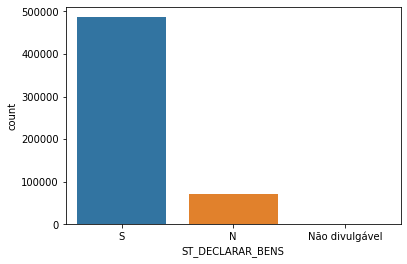

In [ ]:
sns.countplot(x=candidaturas.ST_DECLARAR_BENS)

Segundo a documentação, a coluna 'ST_REELEICAO' contém "#Indica se o candidato está concorrendo ou não à reeleição. Pode assumir os valores: S ¿ Sim e N - Não. Informação autodeclarada pelo candidato." 

In [ ]:
candidaturas.ST_REELEICAO.head(30)

0     N
1     N
2     N
3     N
4     N
5     N
6     S
7     N
8     N
9     N
10    N
11    N
12    N
13    N
14    N
15    N
16    N
17    S
18    N
19    N
20    N
21    N
22    N
23    N
24    N
25    N
26    N
27    N
28    N
29    N
Name: ST_REELEICAO, dtype: object

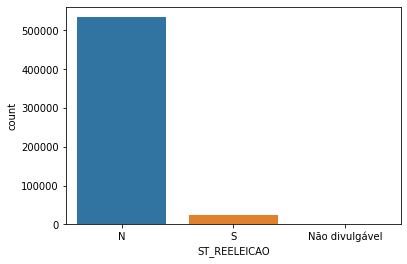

In [ ]:
sns.countplot(x=candidaturas.ST_REELEICAO)

In [ ]:
candidaturas.NM_MUNICIPIO_NASCIMENTO.head(30)

0                  JOÃO PESSOA
1     NOSSA SENHORA DO SOCORRO
2                     IBIMIRIM
3                  SANTO ANDRÉ
4                     BOTUCATU
5                   SOBRADINHO
6     CAPITÃO LEÔNIDAS MARQUES
7                     PEDRO II
8                 BOM CONSELHO
9                     COLATINA
10        AMARANTE DO MARANHÃO
11                       BELÉM
12                     GRAMADO
13                   GARANHUNS
14                MARMELÓPOLIS
15                   MARACANAÚ
16                      GUARAÍ
17                       PICOS
18          LARANJEIRAS DO SUL
19                   CASA NOVA
20                     BRUSQUE
21               VOLTA REDONDA
22                   NOVO LINO
23                  MATELÂNDIA
24                  PONTE NOVA
25                   CANÁPOLIS
26             JOSÉ DE FREITAS
27                   FORTALEZA
28                    BRASÍLIA
29                     ARATIBA
Name: NM_MUNICIPIO_NASCIMENTO, dtype: object

In [ ]:
candidaturas.NM_MUNICIPIO_NASCIMENTO.value_counts(normalize=True)

SÃO PAULO                   0.022403
RIO DE JANEIRO              0.015145
BELO HORIZONTE              0.008409
SALVADOR                    0.007053
RECIFE                      0.006564
                              ...   
MORRO DO CHAPÉU DO PIAUÍ    0.000002
pelotas                     0.000002
APARECIDA DO RIO DOCE       0.000002
Monte Carmelo               0.000002
PUGMIL                      0.000002
Name: NM_MUNICIPIO_NASCIMENTO, Length: 5425, dtype: float64

In [ ]:
candidaturas.DS_COR_RACA.value_counts(normalize=True)

BRANCA            0.480678
PARDA             0.394761
PRETA             0.105167
NÃO INFORMADO     0.011404
INDÍGENA          0.003973
AMARELA           0.003518
NÃO DIVULGÁVEL    0.000500
Name: DS_COR_RACA, dtype: float64

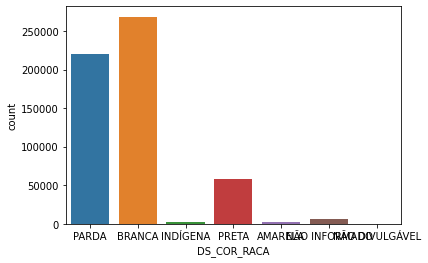

In [ ]:
sns.countplot(x=candidaturas.DS_COR_RACA)

In [ ]:
candidaturas.DS_GRAU_INSTRUCAO.value_counts(normalize=True)

ENSINO MÉDIO COMPLETO            0.380620
SUPERIOR COMPLETO                0.243276
ENSINO FUNDAMENTAL INCOMPLETO    0.127653
ENSINO FUNDAMENTAL COMPLETO      0.121984
ENSINO MÉDIO INCOMPLETO          0.049604
SUPERIOR INCOMPLETO              0.044797
LÊ E ESCREVE                     0.031539
NÃO DIVULGÁVEL                   0.000500
ANALFABETO                       0.000027
Name: DS_GRAU_INSTRUCAO, dtype: float64

In [ ]:
candidaturas.DS_GRAU_INSTRUCAO = pd.Categorical(
    candidaturas.DS_GRAU_INSTRUCAO,[
        'NÃO DIVULGÁVEL', 'ANALFABETO', 'LÊ E ESCREVE',
        'ENSINO FUNDAMENTAL INCOMPLETO', 'ENSINO FUNDAMENTAL COMPLETO',
        'ENSINO MÉDIO INCOMPLETO', 'ENSINO MÉDIO COMPLETO', 'SUPERIOR INCOMPLETO',
        'SUPERIOR COMPLETO'], ordered=True)  

In [ ]:
candidaturas.grau_instrucao = candidaturas.DS_GRAU_INSTRUCAO.cat.codes
candidaturas.grau_instrucao.head(30)

0     3
1     8
2     8
3     5
4     6
5     5
6     8
7     5
8     5
9     6
10    6
11    3
12    7
13    4
14    8
15    6
16    6
17    8
18    8
19    8
20    4
21    8
22    8
23    5
24    3
25    8
26    6
27    6
28    6
29    7
dtype: int8

In [ ]:
mediana =  np.median(candidaturas.DS_GRAU_INSTRUCAO.cat.codes)
mediana

6.0

Como essa informação pode ser interpretada?

EOF